# Algorithms in Layout Algebra

This notebook implements the core algorithms from Cecka,
*CuTe Layout Representation and Algebra* (arXiv:2603.02298v1, §2.6)
using pure layout algebra.

- [**§2.6.1 COPY**](#copy) — element-wise transfer between tensors with different layouts
- [**REDUCE**](#reduce) — accumulation along a mode of a tensor
- [**§2.6.2 GEMM**](#gemm) — matrix multiply: BLAS variants, BLIS GEMM, GETT, Grouped GEMM, CONV
- [**Epilogue Fusion**](#epilogue-fusion) — composing GEMM + broadcast bias + pointwise activation
- [**Online Softmax**](#online-softmax) — fusing REDUCE(max) and REDUCE(sum) into one pass

Each algorithm is expressed with `Tensor` flat indexing (`dst[i] = src[i]`)
and coordinate indexing (`C[m,n] += A[m,k] * B[n,k]`) — the same primitives
a GPU kernel uses, but executed element-by-element so we can visualize the
data movement through different layouts.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="findfont")

In [2]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout, draw_composite, draw_gemm
from tensor_layouts.analysis import *

<a id="copy"></a>

## §2.6.1 COPY

The generic COPY algorithm transfers elements between tensors of equal
size but potentially different layouts.  It is a **rank-1 algorithm**:
it works on tensors of any rank by iterating over the flat index space.

In [3]:
def copy(src: Tensor, dst: Tensor):
    assert size(src) == size(dst)
    for i in range(size(dst)):
        dst[i] = src[i]

`src[i]` decomposes the flat index `i` via `idx2crd` into coordinates,
computes the source offset through the source layout, and reads the
element.  `dst[i]` does the same through the destination layout and
writes.  Different layouts produce different physical orderings —
the copy remaps automatically.

**Table 2** from the paper lists applications that are all just `copy()`
with different source and destination layouts:

| Application | Source Layout | Destination Layout |
|---|---|---|
| 1D Arrays | `8:1` | `8:1` |
| ND Arrays | `(8,2,3):(1,16,32)` | `(8,2,3):(1,16,32)` |
| Gather | `(2,3,2):(42,1,128)` | `12:1` |
| Scatter | `12:1` | `(2,3,2):(42,1,128)` |
| Broadcast | `7:0` | `7:1` |
| Constant | `7:0` | `7:0` |
| Transpose | `(8,3):(1,8)` | `(8,3):(3,1)` |
| Tensor Transpose | `(8,(3,5)):((1,(57,8)))` | `(8,15):(1,8)` |

It is well worth spending time to understand these examples in detail.

### 1D copy

The simplest case: both tensors have the same layout, so the copy is
just a `memcpy()`.  Offsets represent the index from the base address.  The contents of these arrays is represented by letters. For each copy operation we show the offsets on the src and dst layouts, the logical contents of memory as seen through each layout, as well as the content in physical linear-addressed memory.

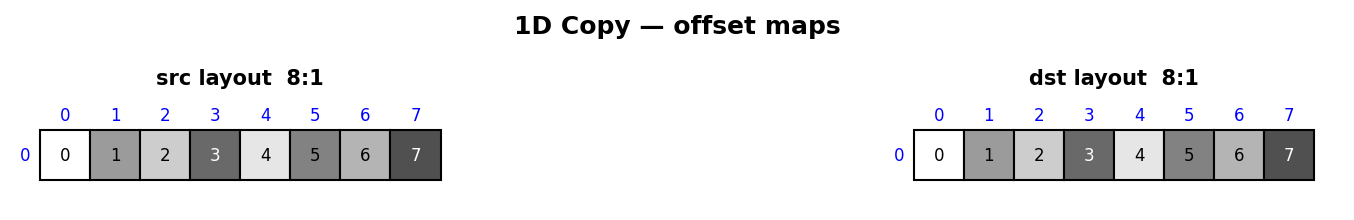

In [4]:
letters = list("ABCDEFGH")
src = Tensor(Layout(8, 1), data=list(letters))
dst = Tensor(Layout(8, 1), data=['.'] * 8)

draw_composite(
    [src.layout, dst.layout],
    titles=['src layout  8:1', 'dst layout  8:1'],
    main_title='1D Copy — offset maps')

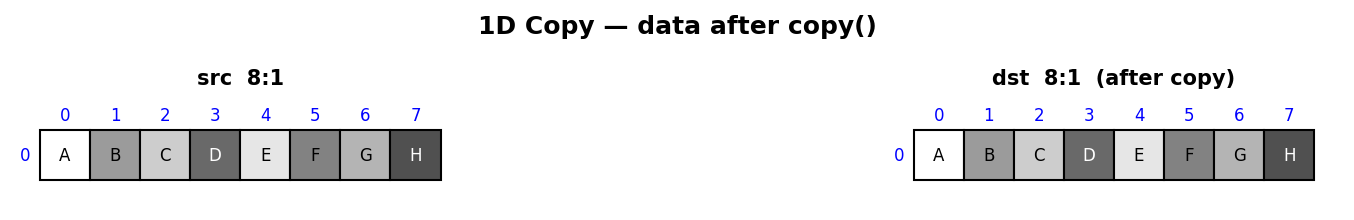

In [5]:
copy(src, dst)

draw_composite([src, dst], titles=['src  8:1', 'dst  8:1  (after copy)'],
               main_title='1D Copy — data after copy()')

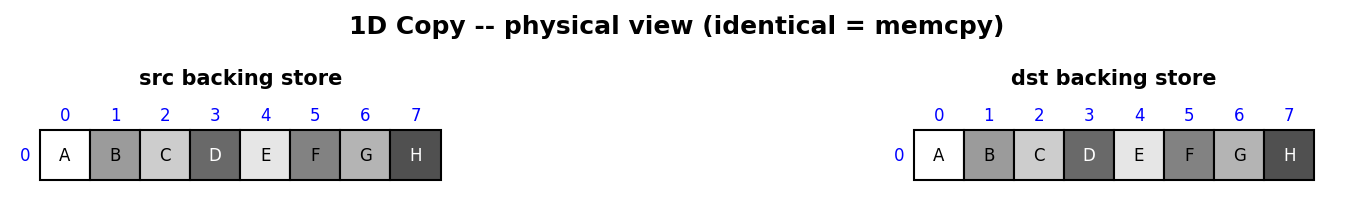

In [6]:
draw_composite(
    [src.view(Layout(len(src.data), 1)), dst.view(Layout(len(dst.data), 1))],
    titles=['src backing store', 'dst backing store'],
    main_title='1D Copy -- physical view (identical = memcpy)')

### Transpose — same `copy()`, different layouts

Row-major `(M,N):(N,1)` → column-major `(M,N):(1,M)`.  The copy
reads elements in row-major order and writes them in column-major
order, effecting a transpose of the physical storage.

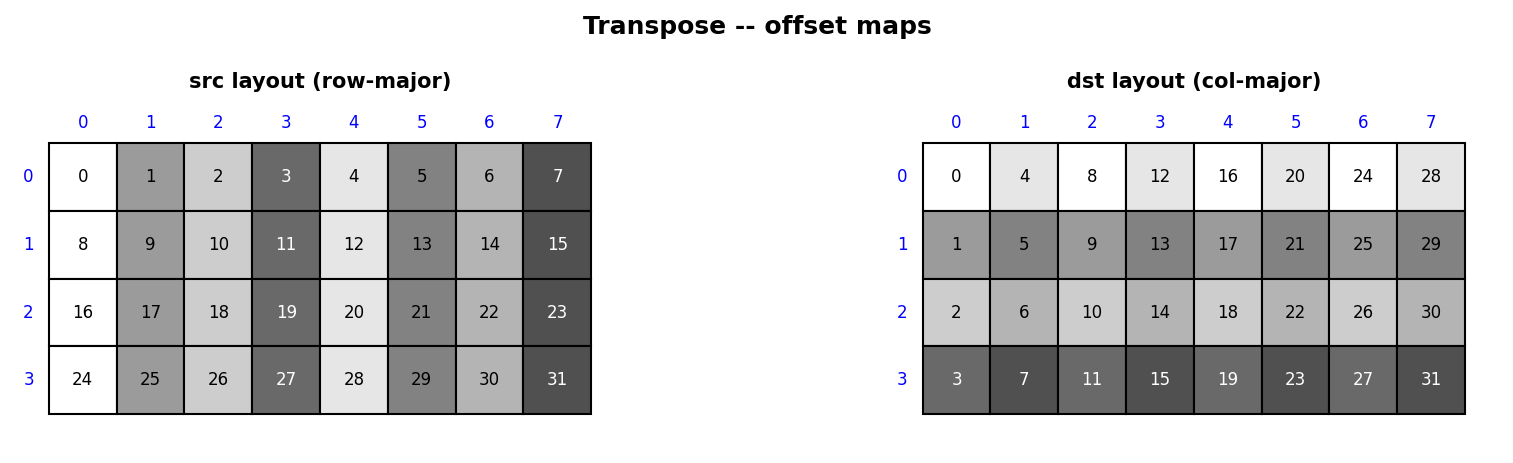

In [7]:
# Transpose: row-major -> col-major using letters
M, N = 4, 8
letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")[:M*N]

src = Tensor(Layout((M, N), (N, 1)), data=list(letters))   # row-major
dst = Tensor(Layout((M, N), (1, M)), data=['.'] * (M*N))   # col-major

# Show layouts (offsets) before copy
draw_composite(
    [src.layout, dst.layout],
    titles=['src layout (row-major)', 'dst layout (col-major)'],
    main_title='Transpose -- offset maps')

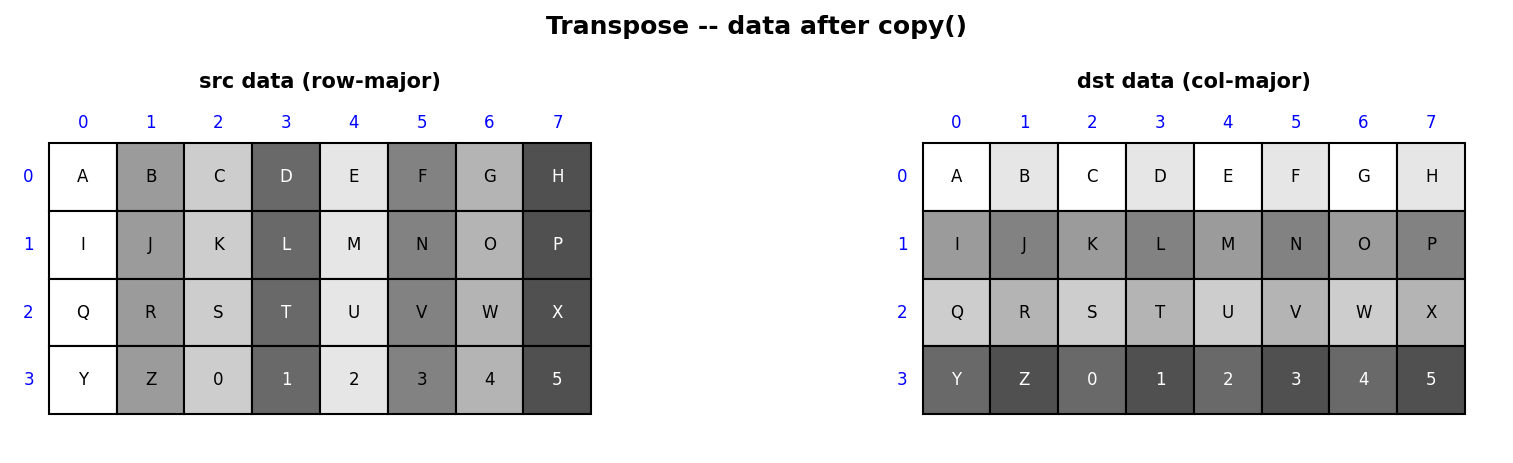

In [8]:
# Perform copy and show data payload
copy(src, dst)

draw_composite(
    [src, dst],
    titles=['src data (row-major)', 'dst data (col-major)'],
    main_title='Transpose -- data after copy()')

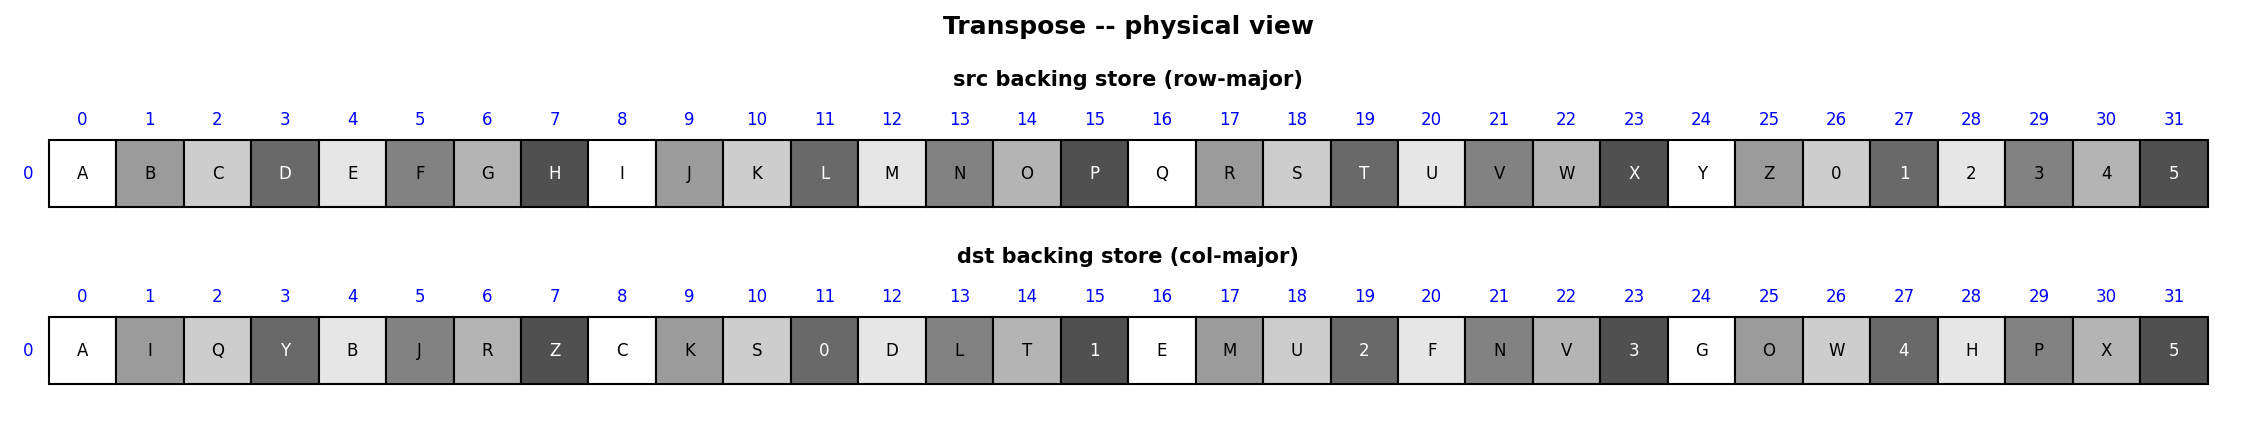

In [9]:
# Physical view: different storage order -- this IS the transpose
draw_composite(
    [src.view(Layout(len(src.data), 1)), dst.view(Layout(len(dst.data), 1))],
    titles=['src backing store (row-major)', 'dst backing store (col-major)'],
    arrangement='vertical',
    main_title='Transpose -- physical view')

### Gather and Scatter

Gather copies from a strided source into contiguous destination.
Scatter is the reverse.  Both are just `copy()` with different layouts.

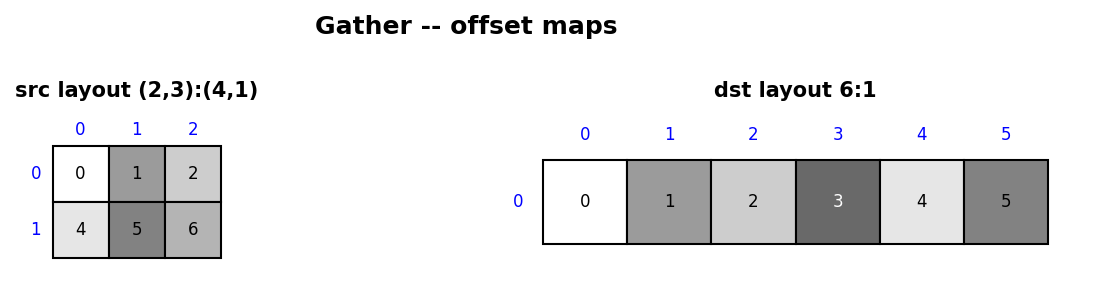

In [10]:
# Gather: strided (2,3):(4,1) -> contiguous 6:1
src_buf = list("ABCDEFGHIJKL") # larger than src
src = Tensor(Layout((2, 3), (4, 1)), data=src_buf)
dst = Tensor(Layout(6, 1), data=['.'] * 6)

draw_composite(
    [src.layout, dst.layout],
    titles=['src layout (2,3):(4,1)', 'dst layout 6:1'],
    main_title='Gather -- offset maps')

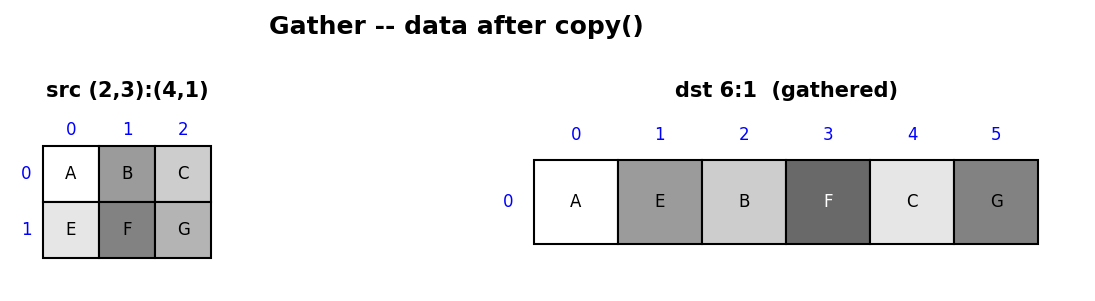

In [11]:
copy(src, dst) # non-contiguous reads, contiguous writes

draw_composite(
    [src, dst],
    titles=['src (2,3):(4,1)', 'dst 6:1  (gathered)'],
    main_title='Gather -- data after copy()')

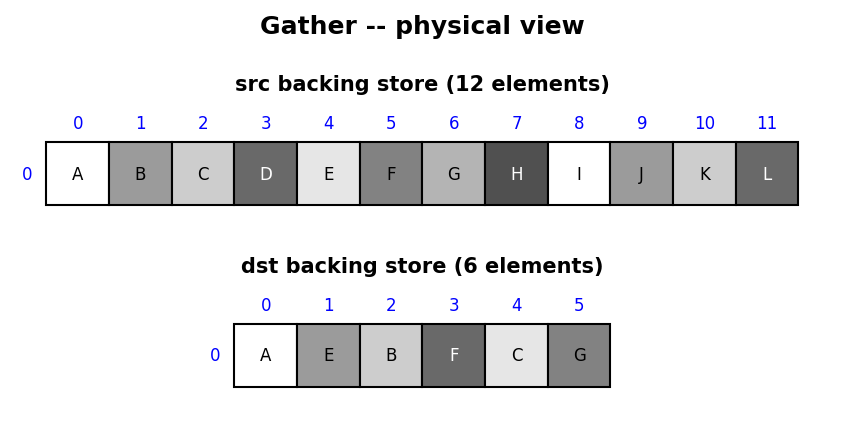

In [12]:
draw_composite(
    [src.view(Layout(len(src.data), 1)), dst.view(Layout(len(dst.data), 1))],
    titles=['src backing store (12 elements)', 'dst backing store (6 elements)'],
    arrangement='vertical',
    main_title='Gather -- physical view')

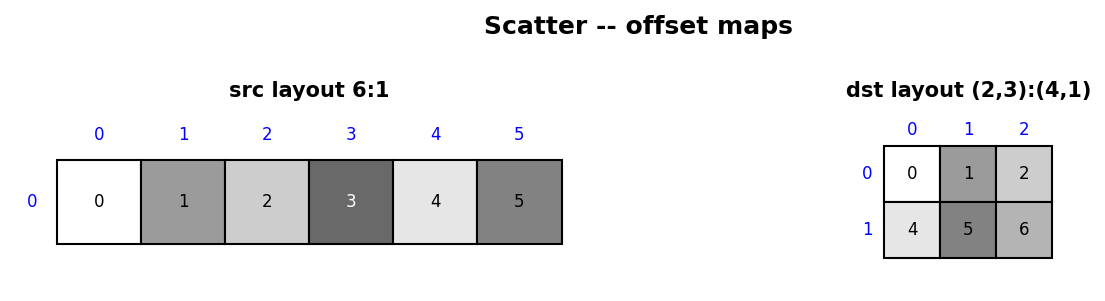

In [13]:
# Scatter: contiguous 6:1 -> strided (2,3):(4,1)
src = Tensor(Layout(6, 1), data=list("ABCDEF"))
dst_buf = ['.'] * 12 # larger than src
dst = Tensor(Layout((2, 3), (4, 1)), data=dst_buf)

draw_composite(
    [src.layout, dst.layout],
    titles=['src layout 6:1', 'dst layout (2,3):(4,1)'],
    main_title='Scatter -- offset maps')

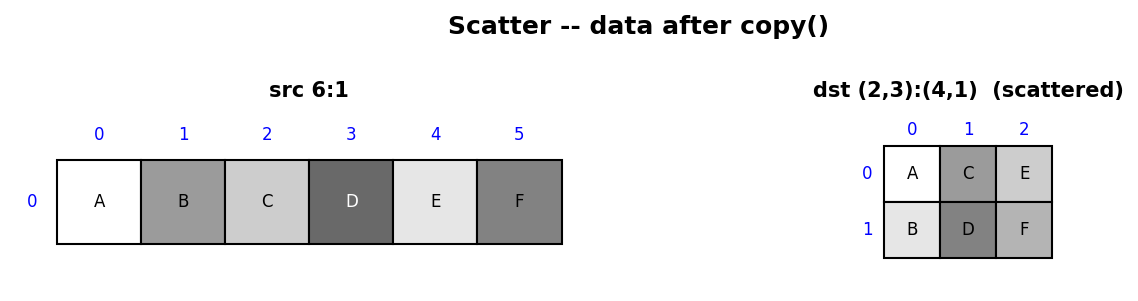

In [14]:
copy(src, dst) # contiguous reads, non-contiguous writes

draw_composite(
    [src, dst],
    titles=['src 6:1', 'dst (2,3):(4,1)  (scattered)'],
    main_title='Scatter -- data after copy()')

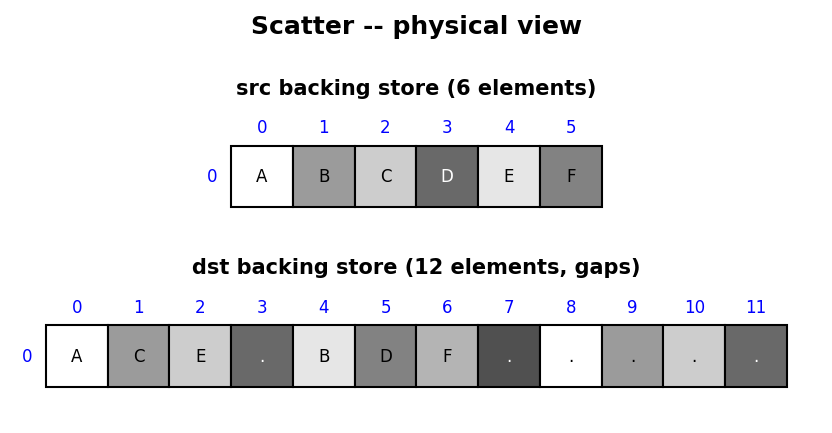

In [15]:
draw_composite(
    [src.view(Layout(len(src.data), 1)), dst.view(Layout(len(dst.data), 1))],
    titles=['src backing store (6 elements)', 'dst backing store (12 elements, gaps)'],
    arrangement='vertical',
    main_title='Scatter -- physical view')

### Broadcast

A stride-0 source layout reads the same element for every index.
Copying into stride-1 broadcasts the single element to all positions.

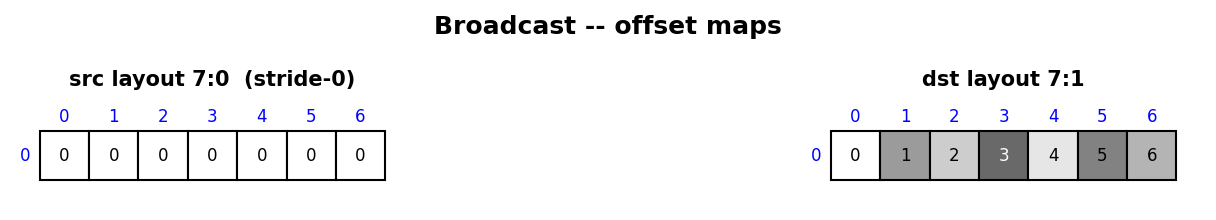

In [16]:
src = Tensor(Layout(7, 0), data=['✔️'])
dst = Tensor(Layout(7, 1), data=['x'] * 7)

draw_composite(
    [src.layout, dst.layout],
    titles=['src layout 7:0  (stride-0)', 'dst layout 7:1'],
    main_title='Broadcast -- offset maps')

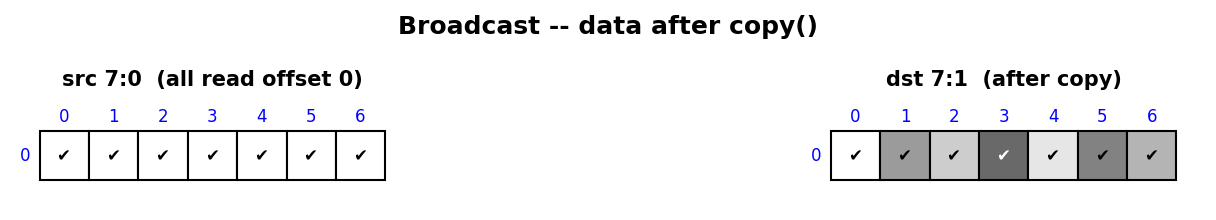

In [17]:
copy(src, dst)

draw_composite(
    [src, dst],
    titles=['src 7:0  (all read offset 0)', 'dst 7:1  (after copy)'],
    main_title='Broadcast -- data after copy()')

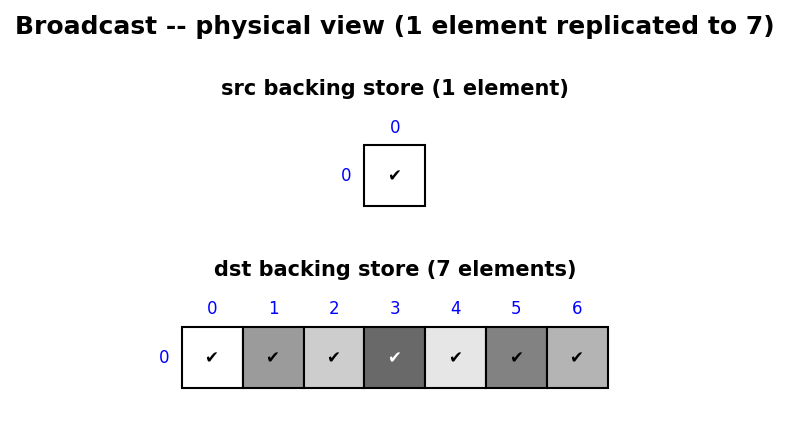

In [18]:
draw_composite(
    [src.view(Layout(len(src.data), 1)), dst.view(Layout(len(dst.data), 1))],
    titles=['src backing store (1 element)', 'dst backing store (7 elements)'],
    arrangement='vertical',
    main_title='Broadcast -- physical view (1 element replicated to 7)')

### Tensor Transpose

A higher-order transpose reshapes a `(4,(2,3))` tensor into `(4,6)`
with different strides — flattening hierarchical modes.

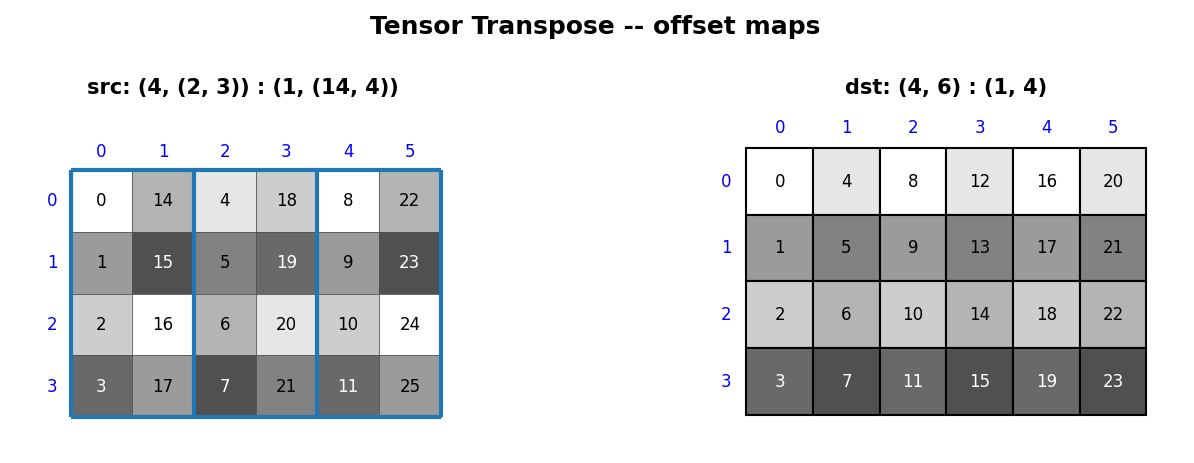

In [19]:
src_layout = Layout((4, (2, 3)), (1, (14, 4)))
dst_layout = Layout((4, 6), (1, 4))

letters = list("ABCDEFGHIJKLMNOPQRSTUVWX")
buf_size = cosize(src_layout)

src = Tensor(src_layout, data=['.'] * buf_size)
for i, letter in enumerate(letters):
    src[i] = letter
dst = Tensor(dst_layout, data=['.'] * cosize(dst_layout))

draw_composite(
    [src_layout, dst_layout],
    titles=[f'src: {src_layout}', f'dst: {dst_layout}'],
    main_title='Tensor Transpose -- offset maps',
    flatten_hierarchical=False, label_hierarchy_levels=False, cell_labels="offset")

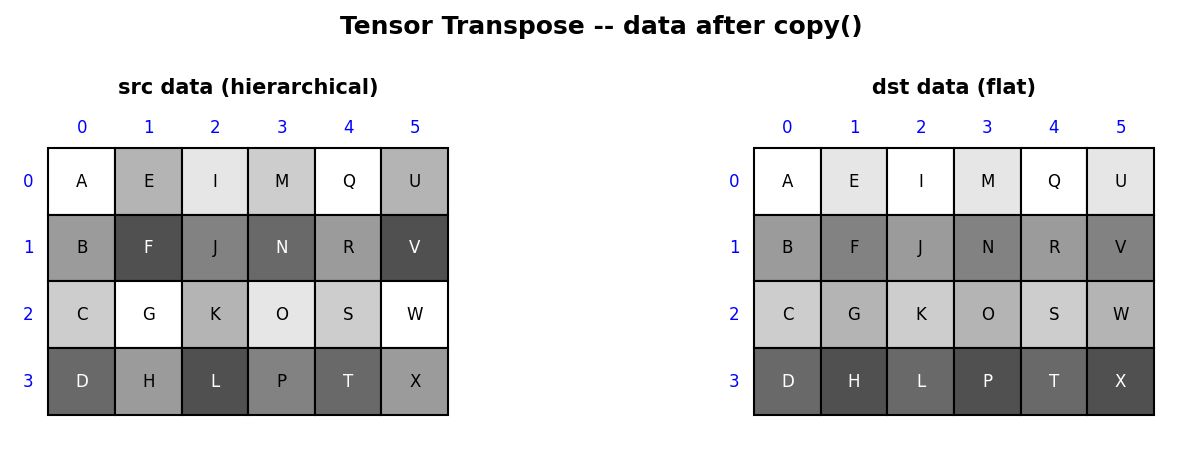

In [20]:
copy(src, dst)

draw_composite(
    [src, dst],
    titles=['src data (hierarchical)', 'dst data (flat)'],
    main_title='Tensor Transpose -- data after copy()',
    flatten_hierarchical=True)

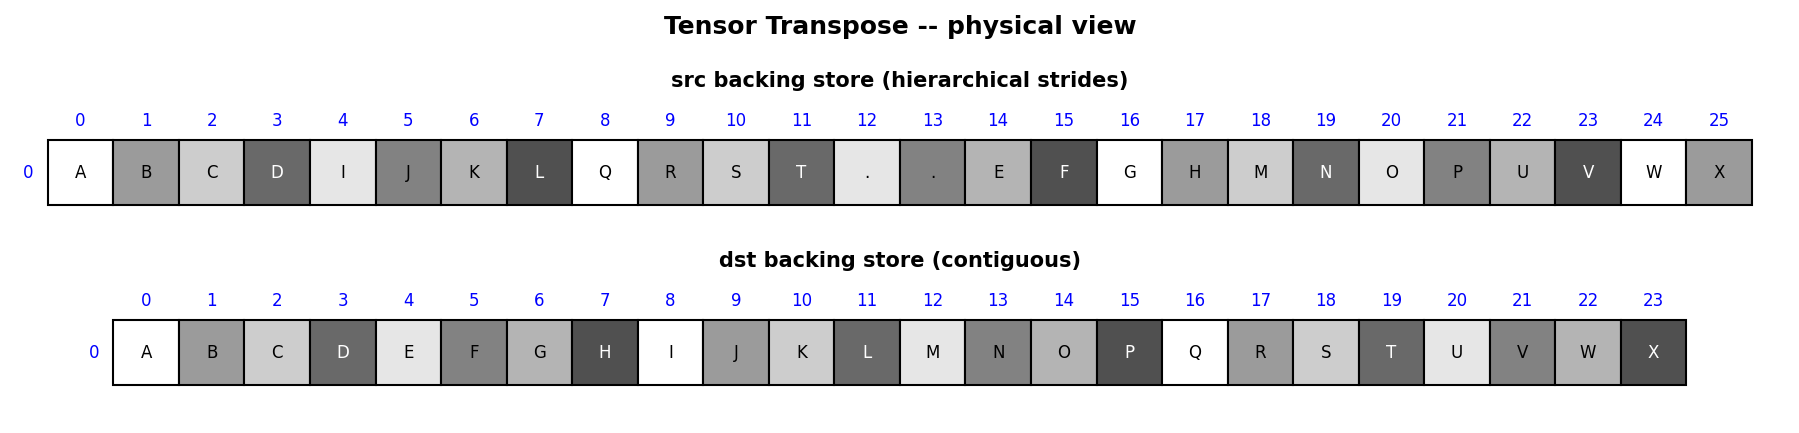

In [21]:
draw_composite(
    [src.view(Layout(len(src.data), 1)), dst.view(Layout(len(dst.data), 1))],
    titles=['src backing store (hierarchical strides)',
            'dst backing store (contiguous)'],
    arrangement='vertical',
    main_title='Tensor Transpose -- physical view')

<a id="reduce"></a>

## REDUCE

The generic REDUCE algorithm accumulates elements along a mode of
a tensor.  It is a **rank-2 algorithm**: two nested loops over
indices M and K.

```python
# REDUCE: dst[m] = op(dst[m], src[m,k])   2 indices, accumulate along K
for k in range(K):
    for m in range(M):
        dst[m] = op(dst[m], src[m, k])
```

Where COPY iterates over a single flat index, REDUCE iterates over
a 2D index space (M × K) and accumulates along the K dimension.
The `op` parameter generalizes `+=` to any binary operator (`max`,
`min`, etc.).

GEMM, which we will see next, extends this pattern with a third loop
over N and a multiply — making it a rank-3 algorithm.

Like COPY, the same `reduce()` function produces different operations
depending on the layouts of src and dst.

In [22]:
def reduce(src: Tensor, dst: Tensor, op=lambda a, b: a + b):
    """Generic REDUCE: accumulate mode 1 of src into dst.
    src: (M, K)  ->  dst: (M,)
    Computes dst[m] = op(dst[m], src[m, k]) for all m, k
    """
    M = size(mode(src, 0))
    K = size(mode(src, 1))
    assert size(dst) == M
    for k in range(K):
        for m in range(M):
            dst[m] = op(dst[m], src[m, k])

Like COPY, different layouts make `reduce()` perform
different operations -- the function itself never changes:

| Application | src Layout | dst Layout | op | What it does |
|---|---|---|---|---|
| Row sum | `(M,K):(K,1)` row-major | `M:1` | `+` | Sum across columns of each row |
| Column sum | `(M,K):(1,M)` col-major | `M:1` | `+` | Sum down rows of each column |
| Strided reduce | `(M,K):(d_m,d_k)` | `M:d_m` | `+` | Generically-strided |
| Max | `(M,K):(K,1)` | `M:1` | `max` | Max per row |
| Tensor reduce | `((M1,M2),K)` | `(M1,M2)` | `+` | Reduce over grouped modes |

Note the parallel with Table 2 (COPY): layout
choices -- not code changes -- determine the semantics.

### Row Sum

Row-major source `(M,K):(K,1)`: mode 0 indexes rows, mode 1 indexes
columns.  `reduce()` accumulates along mode 1 (K), summing each row
into a single output element.

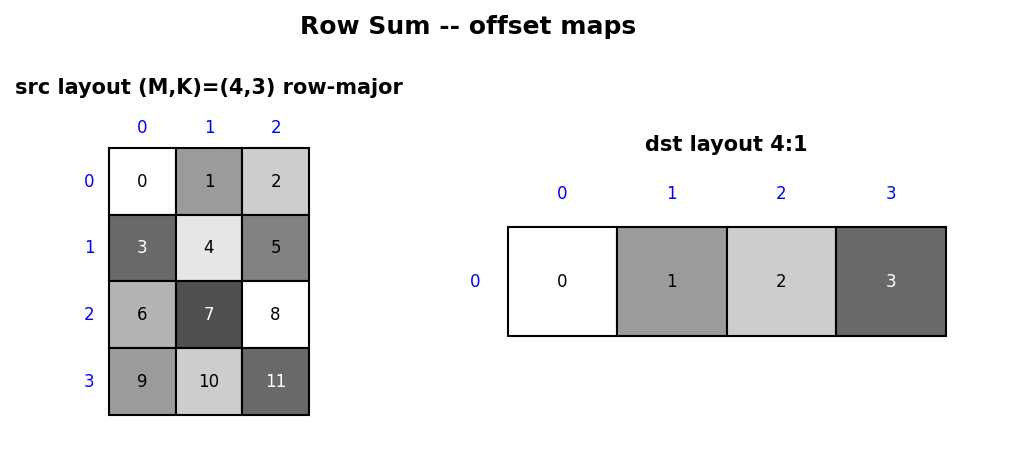

In [23]:
# Row sum: (4,3):(3,1) row-major -> 4:1
M, K = 4, 3
src = Tensor(Layout((M, K), (K, 1)), data=[1., 2., 3.,
                                           4., 5., 6.,
                                           7., 8., 9.,
                                          10.,11.,12.])
dst = Tensor(Layout(M, 1), data=[0.] * M)

draw_composite(
    [src.layout, dst.layout],
    titles=[f'src layout (M,K)=({M},{K}) row-major', f'dst layout {M}:1'],
    main_title='Row Sum -- offset maps')

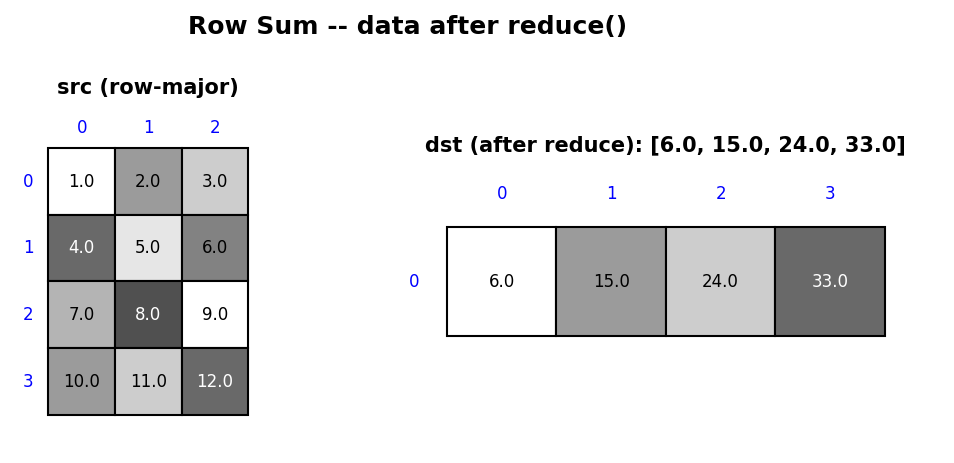

In [24]:
reduce(src, dst)

draw_composite(
    [src, dst],
    titles=['src (row-major)', f'dst (after reduce): {list(dst._data[:size(dst)])}'],
    main_title='Row Sum -- data after reduce()')

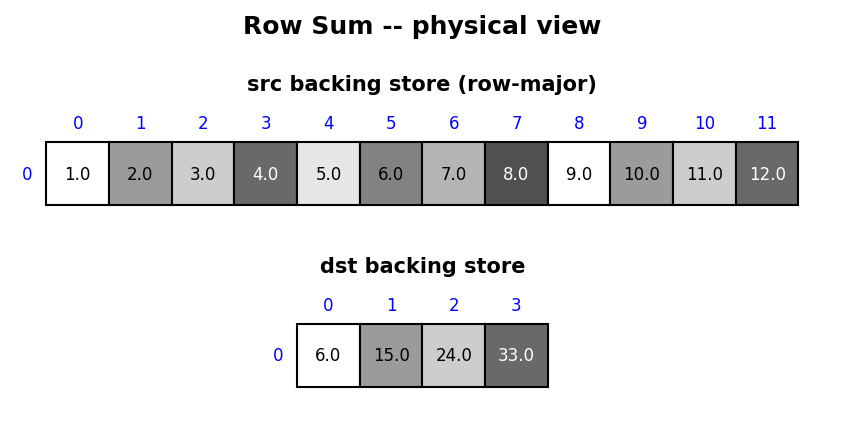

In [25]:
draw_composite(
    [src.view(Layout(len(src._data), 1)), dst.view(Layout(len(dst._data), 1))],
    titles=['src backing store (row-major)', 'dst backing store'],
    arrangement='vertical',
    main_title='Row Sum -- physical view')

### Column Sum -- same `reduce()`, different layout

Column-major source `(M,K):(1,M)`: now mode 0 indexes columns and
mode 1 indexes rows.  The same `reduce()` call accumulates along
mode 1 -- but with col-major strides, that means summing down each
column.  "Row sum" vs "column sum" is purely a layout choice.

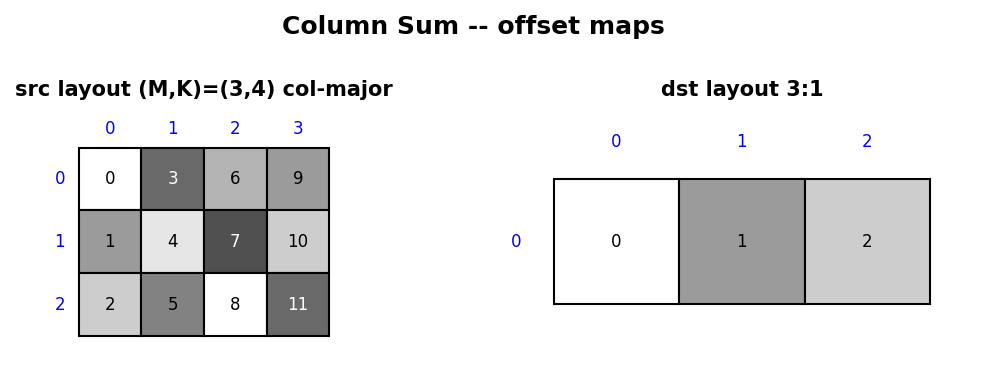

In [26]:
# Column sum: (3,4):(1,3) col-major -> 3:1
# Same 12 values, but now M=3 (columns) and K=4 (rows to sum over)
M, K = 3, 4
src = Tensor(Layout((M, K), (1, M)), data=[ 1.,  2.,  3.,
                                            4.,  5.,  6.,
                                            7.,  8.,  9.,
                                           10., 11., 12.])
dst = Tensor(Layout(M, 1), data=[0.] * M)

draw_composite(
    [src.layout, dst.layout],
    titles=[f'src layout (M,K)=({M},{K}) col-major', f'dst layout {M}:1'],
    main_title='Column Sum -- offset maps')

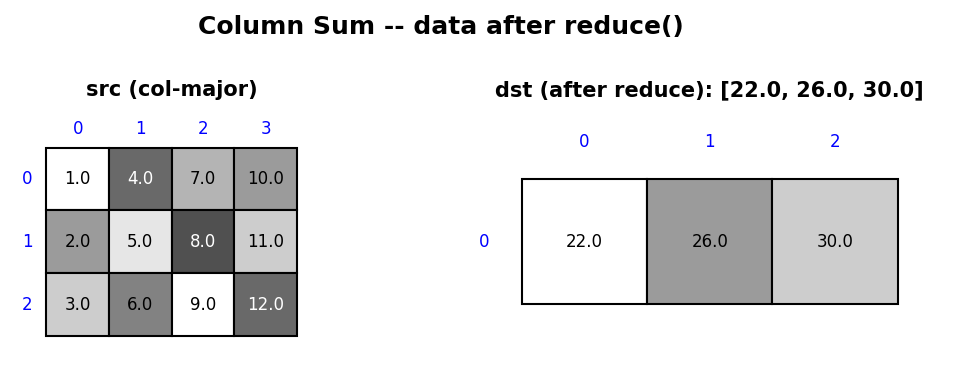

In [27]:
reduce(src, dst)

draw_composite(
    [src, dst],
    titles=['src (col-major)', f'dst (after reduce): {list(dst._data[:size(dst)])}'],
    main_title='Column Sum -- data after reduce()')

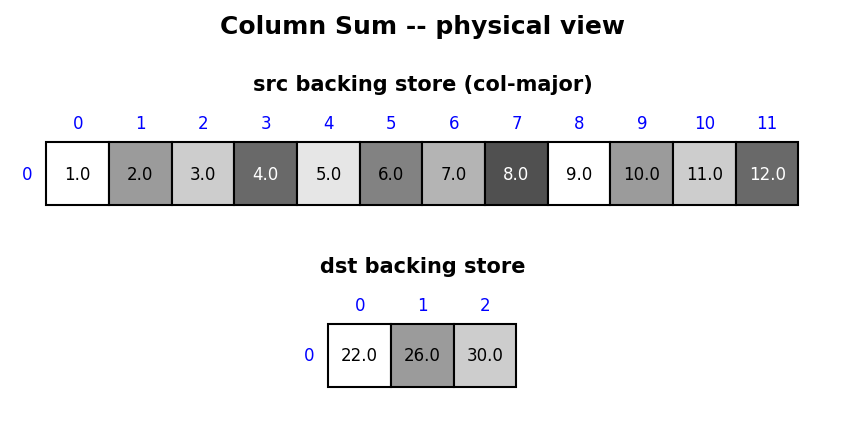

In [28]:
draw_composite(
    [src.view(Layout(len(src._data), 1)), dst.view(Layout(len(dst._data), 1))],
    titles=['src backing store (col-major)', 'dst backing store'],
    arrangement='vertical',
    main_title='Column Sum -- physical view')

### Max Reduction -- different operator

Same `reduce()` function, same row-major layout, but `op=max` instead
of `+`.  The operator is the only thing that changes -- layout algebra
handles the data movement, the operator handles the semantics.

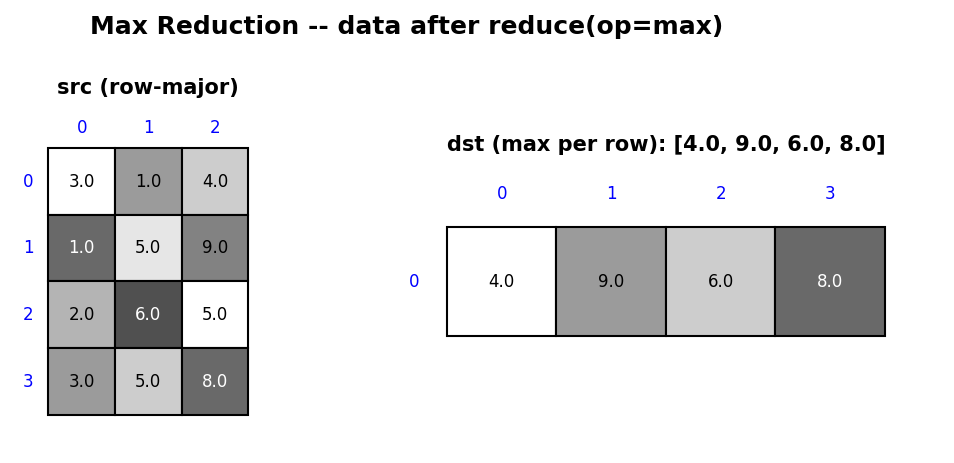

In [29]:
# Max reduction: row-major (4,3):(3,1) -> 4:1 with op=max
M, K = 4, 3
src = Tensor(Layout((M, K), (K, 1)), data=[3., 1., 4.,
                                           1., 5., 9.,
                                           2., 6., 5.,
                                           3., 5., 8.])
dst = Tensor(Layout(M, 1), data=[float('-inf')] * M)

reduce(src, dst, op=max)

draw_composite(
    [src, dst],
    titles=['src (row-major)', f'dst (max per row): {list(dst._data[:size(dst)])}'],
    main_title='Max Reduction -- data after reduce(op=max)')

<a id="gemm"></a>

## §2.6.2 GEMM

The generic GEMM algorithm computes `C += A × B`.  It is a **rank-3
algorithm**: GEMM extends REDUCE by adding the N dimension and a
multiply, giving three nested loops over M, N, K.

- `A` has shape `(M, K)` — M rows, K columns
- `B` has shape `(N, K)` — N rows, K columns (note: B is transposed vs. math convention)
- `C` has shape `(M, N)` — M rows, N columns


In [30]:
def gemm(A: Tensor, B: Tensor, C: Tensor):
    """Generic GEMM
    A: (M, K),  B: (N, K),  C: (M, N)
    Computes C += A × Bᵀ
    """
    M = size(mode(A, 0))
    N = size(mode(B, 0))
    K = size(mode(A, 1))
    assert size(mode(B, 1)) == K
    assert size(mode(C, 0)) == M
    assert size(mode(C, 1)) == N

    for k in range(K):
        for n in range(N):
            for m in range(M):
                C[m, n] += A[m, k] * B[n, k]

By varying the layouts of A, B, C we get every BLAS transpose variant,
generically-strided BLIS GEMM, tensor contractions (GETT), grouped GEMM,
and convolutions (CONV) — all from the same 4-line loop nest.

**Table 3** from the paper (extended with Grouped GEMM):

| Application | A-Layout | B-Layout | C-Layout |
|---|---|---|---|
| NT GEMM | `(M,K):(1,lda)` | `(N,K):(1,ldb)` | `(M,N):(1,ldc)` |
| TN GEMM | `(M,K):(lda,1)` | `(N,K):(ldb,1)` | `(M,N):(1,ldc)` |
| NTT GEMM | `(N,K):(1,ldb)` | `(M,K):(1,lda)` | `(N,M):(1,ldc)` |
| BLIS GEMM | `(M,K):(dm,dk)` | `(N,K):(dn,dk)` | `(M,N):(dm,dn)` |
| GETT | `((M₁,M₂),K):((1,W),X)` | `(N,K):(K,1)` | `((M₁,M₂),N):((1,Y),Z)` |
| Grouped GEMM | `((M,G),K)` | `(N,K)` | `((M,G),N)` |
| CONV | `(K,(C,T,R,S)):D_A` | `((N,Z,P,Q),(C,T,R,S)):D_B` | `(K,(N,Z,P,Q)):D_C` |

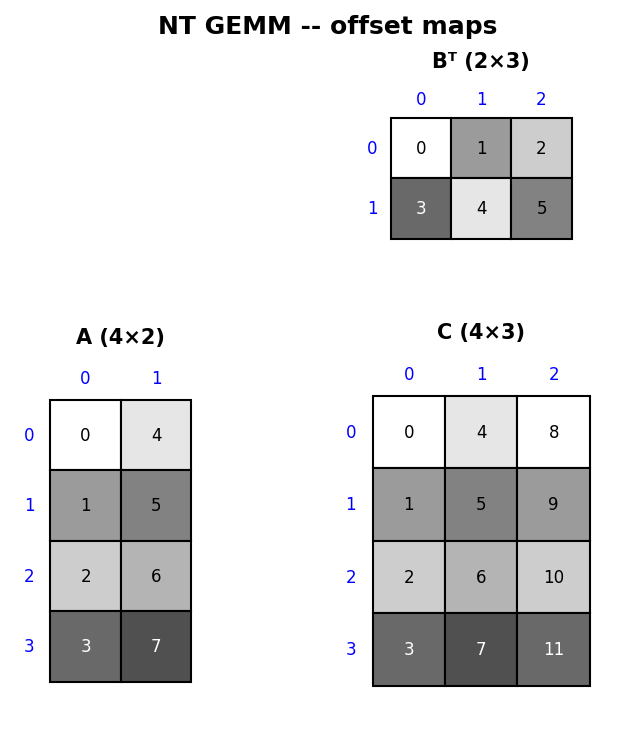

In [31]:
# NT GEMM: col-major A, B, C
M, N, K = 4, 3, 2

A_data = [1., 0., 0., 1.,  2., 1., 1., 0.]  # 4×2
B_data = [1., 0., 1.,  0., 1., 1.]        # 3×2
C_data = [0.] * (M * N)

A = Tensor(Layout((M, K), (1, M)), data=A_data)   # col-major
B = Tensor(Layout((N, K), (1, N)), data=B_data)   # col-major
C = Tensor(Layout((M, N), (1, M)), data=C_data)   # col-major

draw_gemm(A.layout, B.layout, C.layout,
          main_title='NT GEMM -- offset maps')

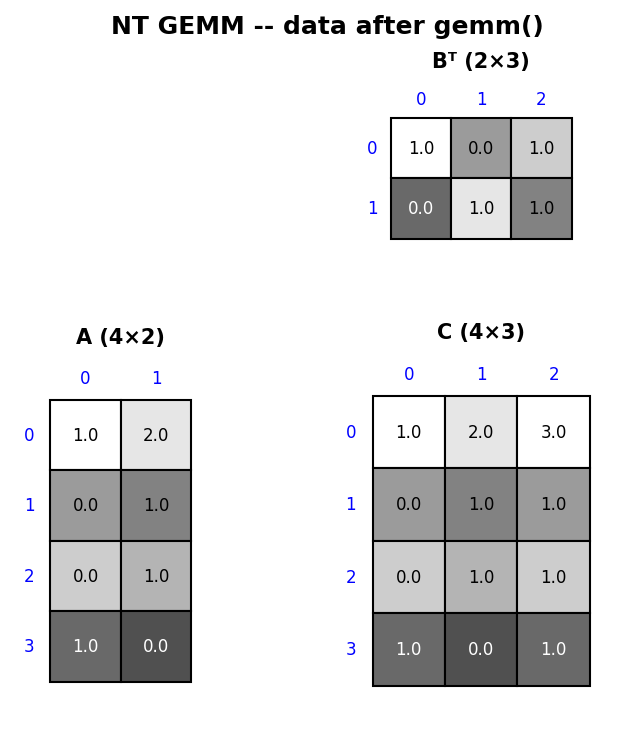

In [32]:
gemm(A, B, C)

draw_gemm(A, B, C,
          main_title='NT GEMM -- data after gemm()')

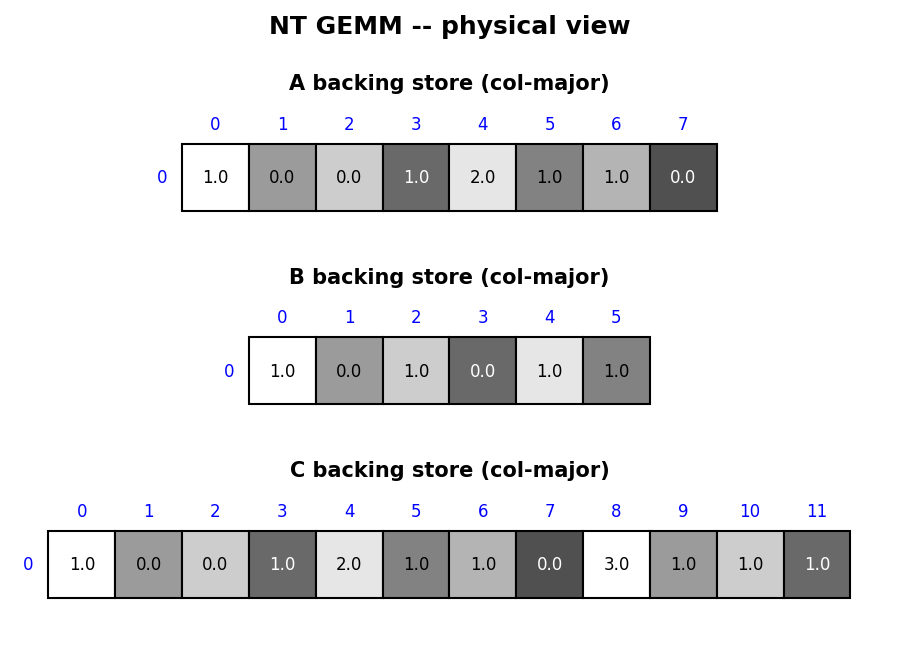

In [33]:
draw_composite(
    [A.view(Layout(len(A.data), 1)), B.view(Layout(len(B.data), 1)), C.view(Layout(len(C.data), 1))],
    titles=['A backing store (col-major)', 'B backing store (col-major)', 'C backing store (col-major)'],
    arrangement='vertical',
    main_title='NT GEMM -- physical view')

### TN GEMM (row-major A and B)

A is transposed (row-major), B is not transposed (row-major).
Same `gemm()` function, just different strides.

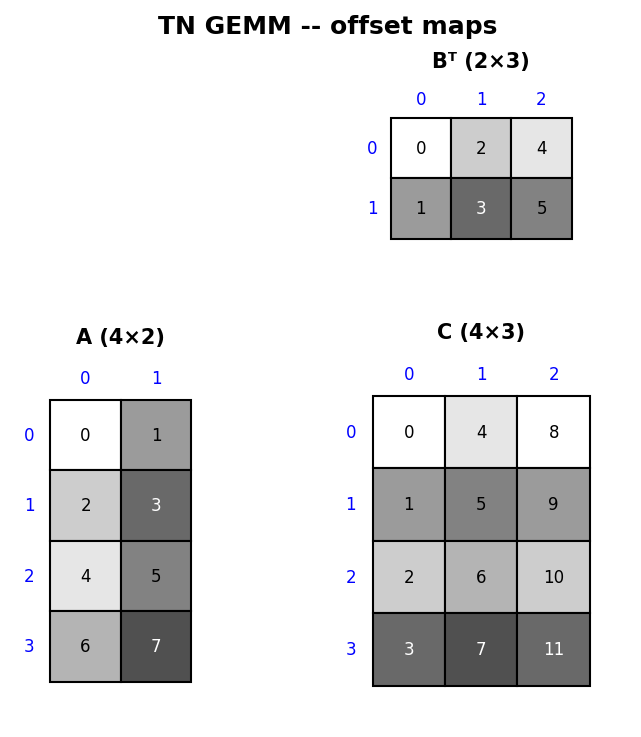

In [34]:
# TN GEMM: row-major A and B, col-major C
M, N, K = 4, 3, 2

A = Tensor(Layout((M, K), (K, 1)), data=[1., 2., 0., 1., 0., 1., 1., 0.])  # row-major
B = Tensor(Layout((N, K), (K, 1)), data=[1., 0., 0., 1., 1., 1.])          # row-major
C = Tensor(Layout((M, N), (1, M)), data=[0.] * (M * N))                    # col-major

draw_gemm(A.layout, B.layout, C.layout,
          main_title='TN GEMM -- offset maps')

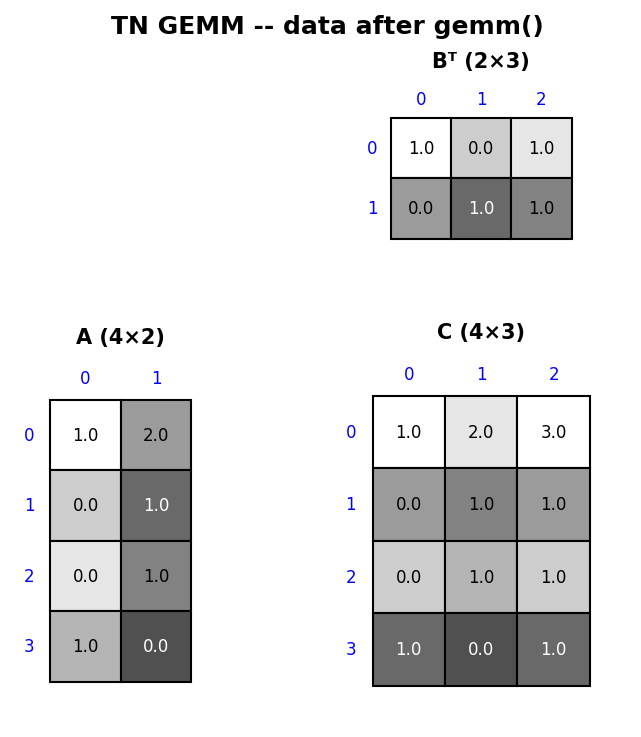

In [35]:
gemm(A, B, C)

draw_gemm(A, B, C,
          main_title='TN GEMM -- data after gemm()')

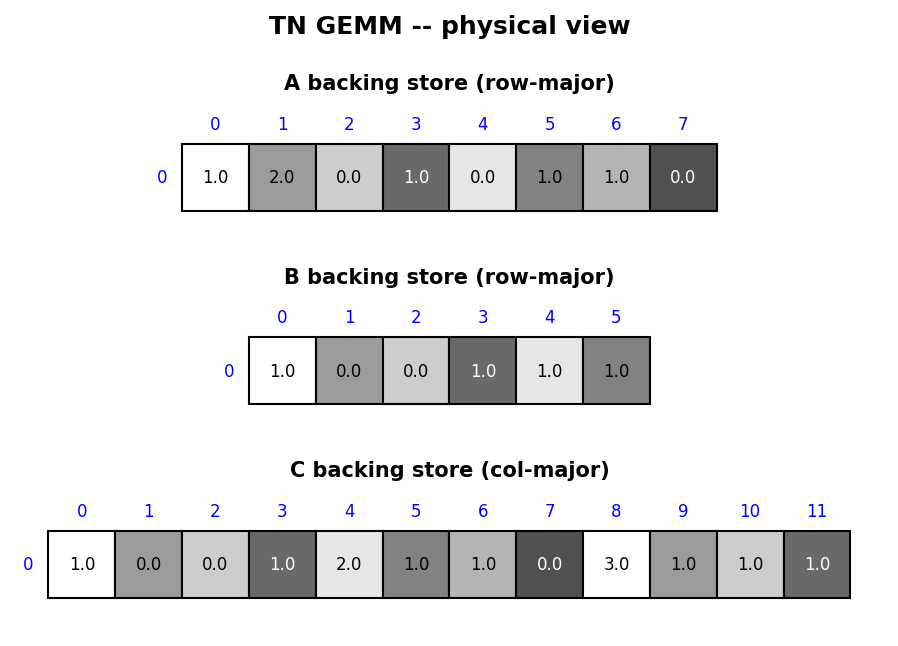

In [36]:
draw_composite(
    [A.view(Layout(len(A.data), 1)), B.view(Layout(len(B.data), 1)), C.view(Layout(len(C.data), 1))],
    titles=['A backing store (row-major)', 'B backing store (row-major)', 'C backing store (col-major)'],
    arrangement='vertical',
    main_title='TN GEMM -- physical view')

### GETT — Generalized Tensor-Tensor contraction

Any tensor contraction can be expressed as GEMM by grouping modes into
M (row), N (column), and K (reduction) groups.  Hierarchical shapes
keep the original tensor structure visible.

Example: contract a `(M₁, M₂, K)` tensor with a `(N, K)` tensor to produce
a `(M₁, M₂, N)` result — the two M modes are grouped into GEMM's M dimension.

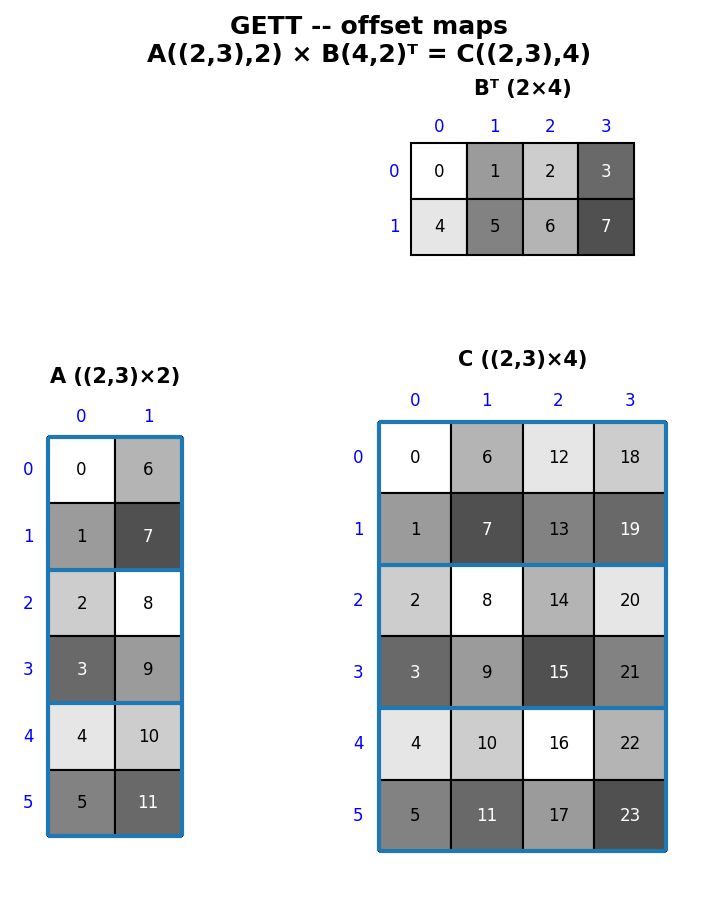

In [37]:
# GETT: A has shape ((M1,M2), K), B has shape (N, K)
M1, M2, Ng, Kg = 2, 3, 4, 2

A = Tensor(Layout(((M1, M2), Kg), ((1, M1), M1*M2)), data=[float(x) for x in range(M1*M2*Kg)])
B = Tensor(Layout((Ng, Kg), (1, Ng)),                data=[float(x) for x in range(Ng*Kg)])
C = Tensor(Layout(((M1, M2), Ng), ((1, M1), M1*M2)), data=[0.] * (M1*M2*Ng))

draw_gemm(A.layout, B.layout, C.layout,
          main_title=f'GETT -- offset maps\nA(({M1},{M2}),{Kg}) × B({Ng},{Kg})ᵀ = C(({M1},{M2}),{Ng})')

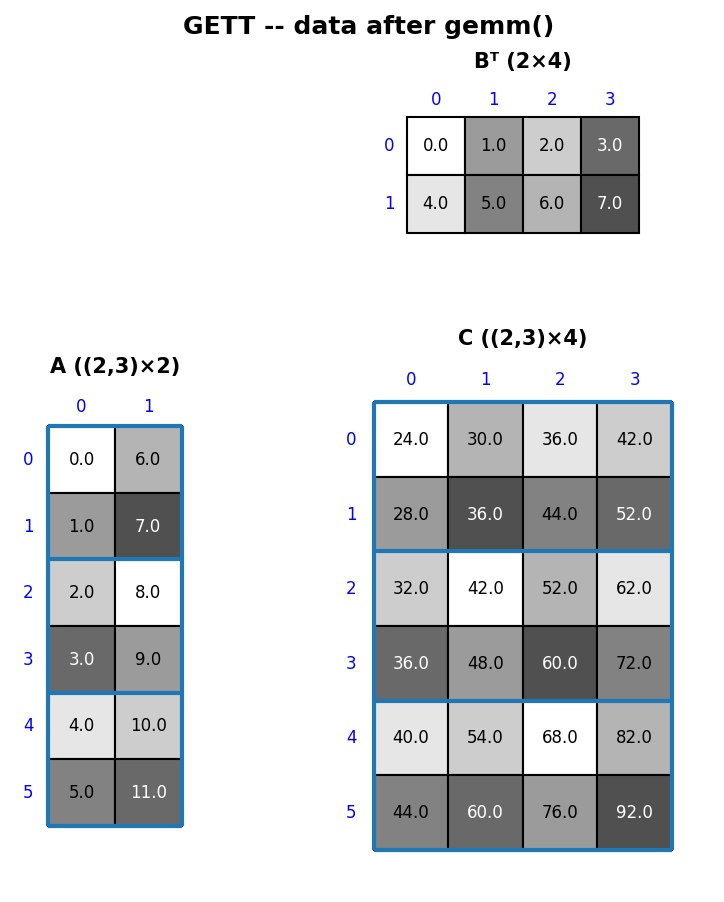

In [38]:
gemm(A, B, C)

draw_gemm(A, B, C,
          main_title='GETT -- data after gemm()')

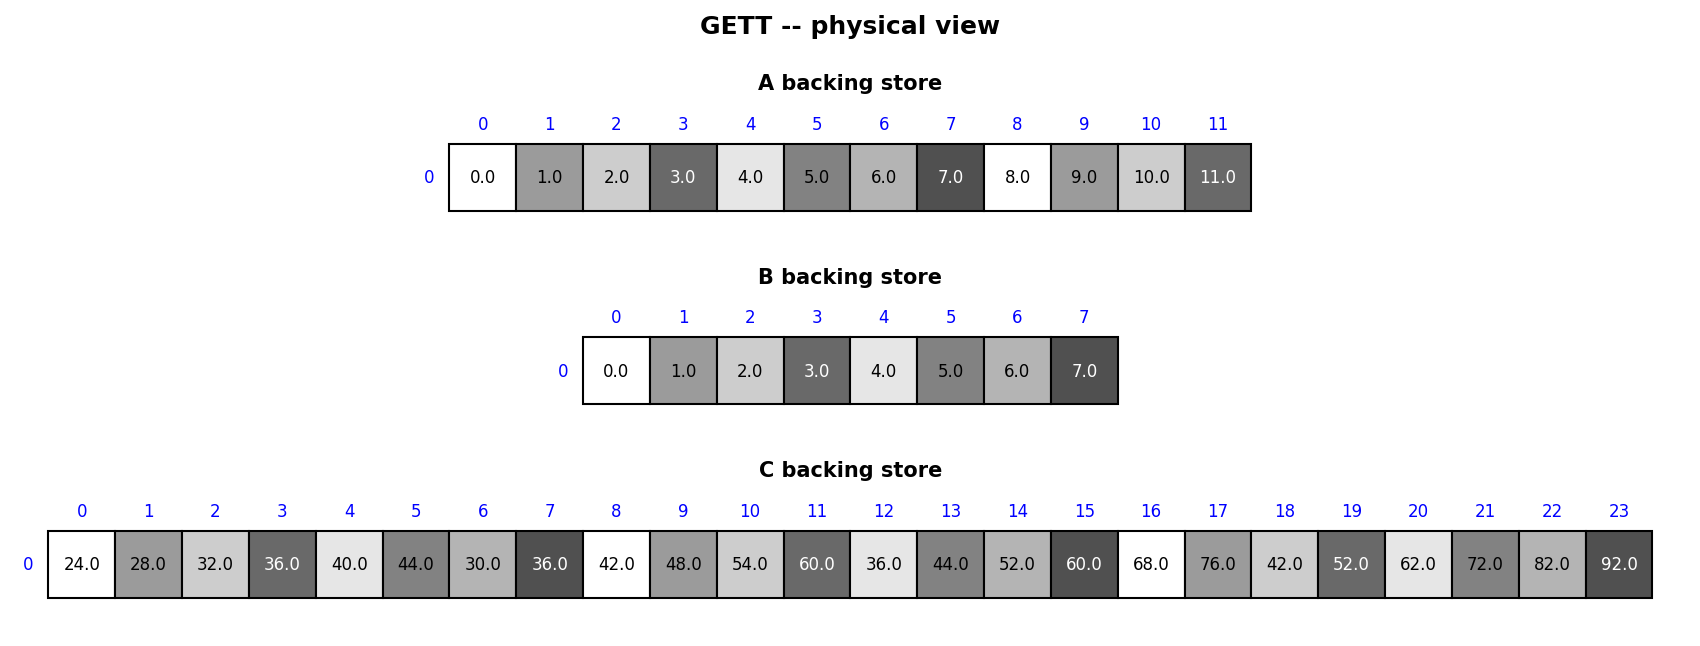

In [39]:
draw_composite(
    [A.view(Layout(len(A.data), 1)), B.view(Layout(len(B.data), 1)), C.view(Layout(len(C.data), 1))],
    titles=['A backing store', 'B backing store', 'C backing store'],
    arrangement='vertical',
    main_title='GETT -- physical view')

### Grouped GEMM — Batching as GETT

A common workload is **grouped GEMM**: compute G independent matrix
multiplies `C_g += A_g × B_g^T` for `g = 0, 1, ..., G-1`, all with
the same dimensions M, N, K.

When the operands share a common factor — typically B is the same
across all groups (as in multi-head attention where the projection
weights are shared) — the group dimension folds directly into GETT.
Stack the G copies of A into a single tensor with hierarchical shape
`((M, G), K)`, keep B as `(N, K)`, and the output becomes `((M, G), N)`.
The same `gemm()` function handles all G groups in one call — no loop,
no code change, just different layouts.

Even when each group has its own B_g, we can fold G into **both** M and N:
A becomes `((M, G), K)` and B becomes `((N, G), K)`. This still works with
`gemm()`, but produces a `((M, G), (N, G))` output — all G² cross-group
products, not just the G diagonal blocks we want.  The extra results are
computed and discarded, which is wasteful but algebraically valid.

The example below shows the shared-B case: 3 groups of 2×2 GEMM with
a common 2×2 matrix B.

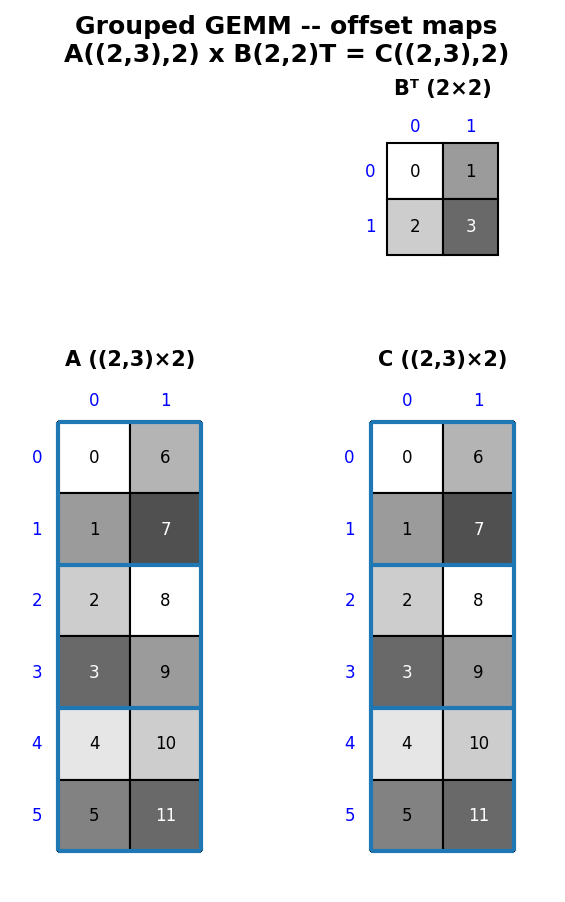

In [40]:
# Grouped GEMM: G=3 groups of 2x2 GEMM, shared B
M, N, K, G = 2, 2, 2, 3

# Stack G copies of A into ((M, G), K) -- each group's 2x2 block is contiguous
A_data = [1., 2., 3., 4.,   # group 0
          5., 6., 7., 8.,   # group 1
          9.,10.,11.,12.] # group 2
A = Tensor(Layout(((M, G), K), ((1, M), M*G)), data=A_data)

# Shared B: (N, K) -- same for all groups
B = Tensor(Layout((N, K), (1, N)), data=[1., 0., 0., 1.])   # identity

# Output: ((M, G), N)
C = Tensor(Layout(((M, G), N), ((1, M), M*G)), data=[0.] * (M*G*N))

draw_gemm(A.layout, B.layout, C.layout,
          main_title='Grouped GEMM -- offset maps\nA((2,3),2) x B(2,2)T = C((2,3),2)')

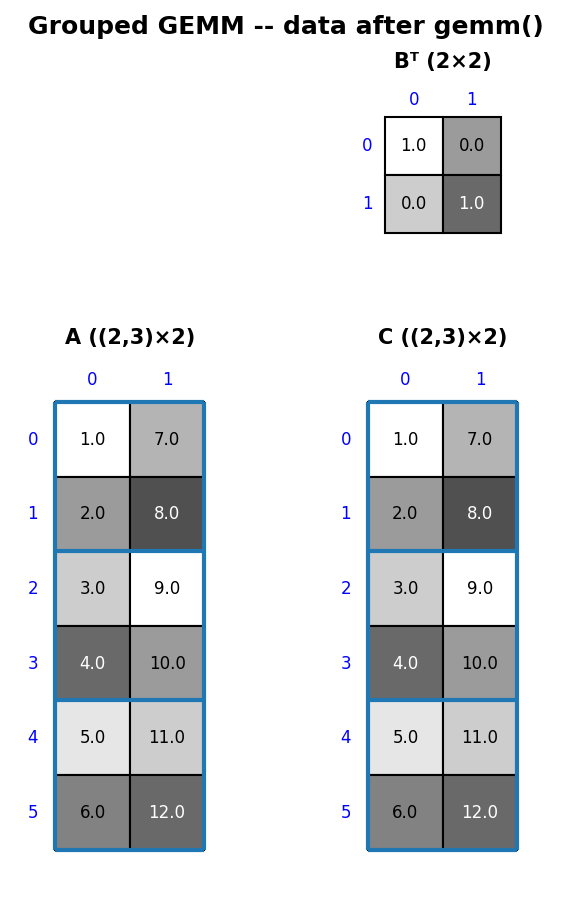

In [41]:
gemm(A, B, C)

draw_gemm(A, B, C,
          main_title='Grouped GEMM -- data after gemm()')

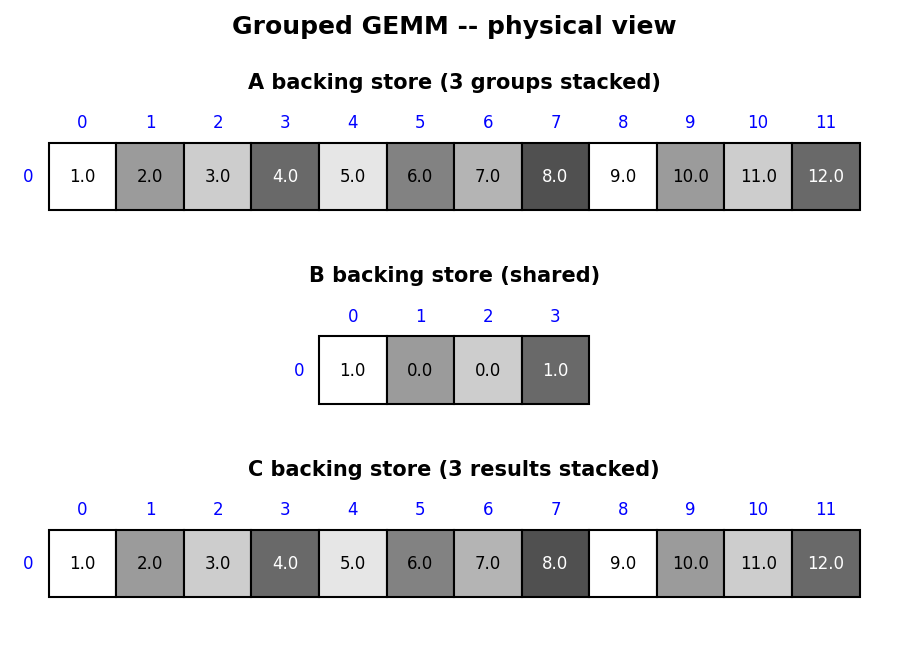

In [42]:
draw_composite(
    [A.view(Layout(len(A.data), 1)), B.view(Layout(len(B.data), 1)), C.view(Layout(len(C.data), 1))],
    titles=['A backing store (3 groups stacked)', 'B backing store (shared)', 'C backing store (3 results stacked)'],
    arrangement='vertical',
    main_title='Grouped GEMM -- physical view')

### Beyond Layout Algebra: Variable-Size Grouped GEMM

The shared-B grouped GEMM above works because folding G into M is
exactly GETT -- the group index is just another mode in a hierarchical
shape.  Two harder variants do **not** fit cleanly into layout algebra:

**Fully-independent batched GEMM** (each group has its own A_g *and* B_g):
Folding G into both M and N makes `gemm()` compute the full
`((M·G), (N·G))` output -- including all G² cross-group products
`C[(m, g_a), (n, g_b)]` for every pair `(g_a, g_b)`.  We only want
the G diagonal blocks where `g_a = g_b`.  Layout algebra maps coordinates
to offsets; it has no mechanism to *mask* or *skip* unwanted index
combinations.  The practical solution is G separate `gemm()` calls.

**Variable-size grouped GEMM** (different M_g, N_g, K_g per group):
This is even further outside the paradigm.  A Layout's shape is fixed at
construction -- there is no single layout that describes groups with different
dimensions.  Variable-size grouped GEMM is a scheduling and dispatch problem
(which group runs on which SM, how to pack irregular tiles into shared
memory), not an algebra problem.  Libraries like CUTLASS handle this with
explicit group tables and runtime dispatch rather than layout composition.

### CONV — Convolution as implicit GEMM

Convolution maps to GEMM by treating the filter as A and the
`im2col`-rearranged input as B.  The key insight is that the B
tensor's layout encodes the `im2col` transformation implicitly —
no explicit data rearrangement is needed.

Traditionally, `im2col` **copies** each sliding window into a row
of a new matrix so convolution becomes a standard GEMM:

```python
def im2col(signal, P, S):
    """Explicitly build the im2col matrix for 1D convolution."""
    col = []
    for p in range(P):           # each output position
        for s in range(S):       # each filter tap
            col.append(signal[p + s])   # gather from input
    return col   # flat P*S buffer, row-major
```

For `signal = [0, 1, 3, 2, 4, 1]` with `S=3`, `P=4`:

```
im2col =  [[0, 1, 3],    ← signal[0:3]
           [1, 3, 2],    ← signal[1:4]
           [3, 2, 4],    ← signal[2:5]
           [2, 4, 1]]    ← signal[3:6]
```

With CuTe layouts, we skip the copy entirely.  A `(P, S):(1, 1)`
layout over the original signal produces the same overlapping windows:
`B[p, s]` reads `signal[p·1 + s·1] = signal[p + s]` — the same
gather, expressed as a layout rather than a data copy.

For a simple 1D convolution with input length `W`, filter size `S`,
and `K` output channels:
- A (filter): shape `(K, S)` — K filters of width S
- B (input):  shape `(P, S)` — P output positions, S taps per position
- C (output): shape `(K, P)` — K channels × P positions

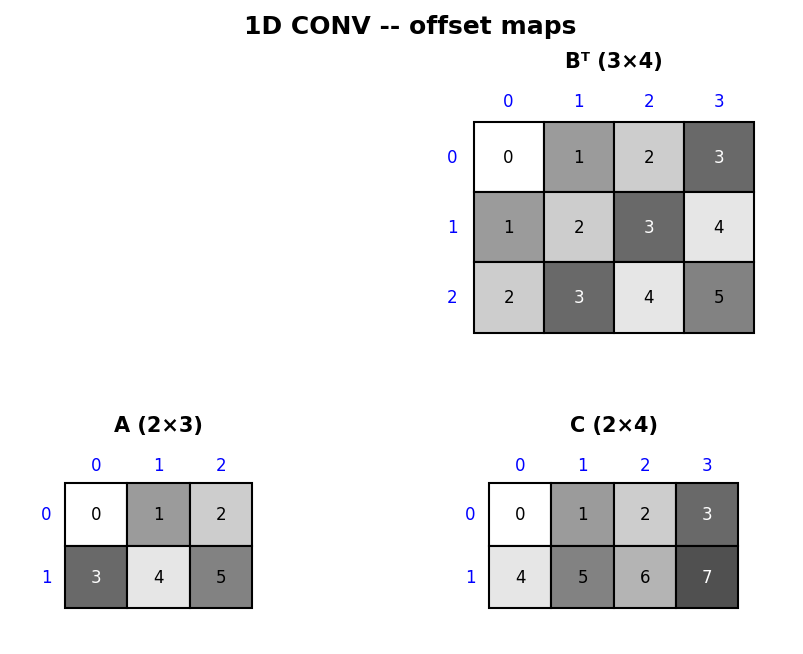

In [43]:
# 1D Convolution: input_len=6, filter_size=3, num_filters=2
W, S, K = 6, 3, 2
P = W - S + 1  # output positions = 4

# Filter: K filters of width S (row-major)
filters = [1., 0., -1.,   # filter 0: edge detector
           1., 1.,  1.]   # filter 1: box filter
A = Tensor(Layout((K, S), (S, 1)), data=filters)

# Input signal
signal = [0., 1., 3., 2., 4., 1.]

# B = im2col view of input: shape (P, S), stride (1, 1)
# B[p, s] reads signal[p + s] — the sliding window!
B = Tensor(Layout((P, S), (1, 1)), data=signal)

# Output: K × P
C = Tensor(Layout((K, P), (P, 1)), data=[0.] * (K * P))

draw_gemm(A.layout, B.layout, C.layout,
          main_title='1D CONV -- offset maps')

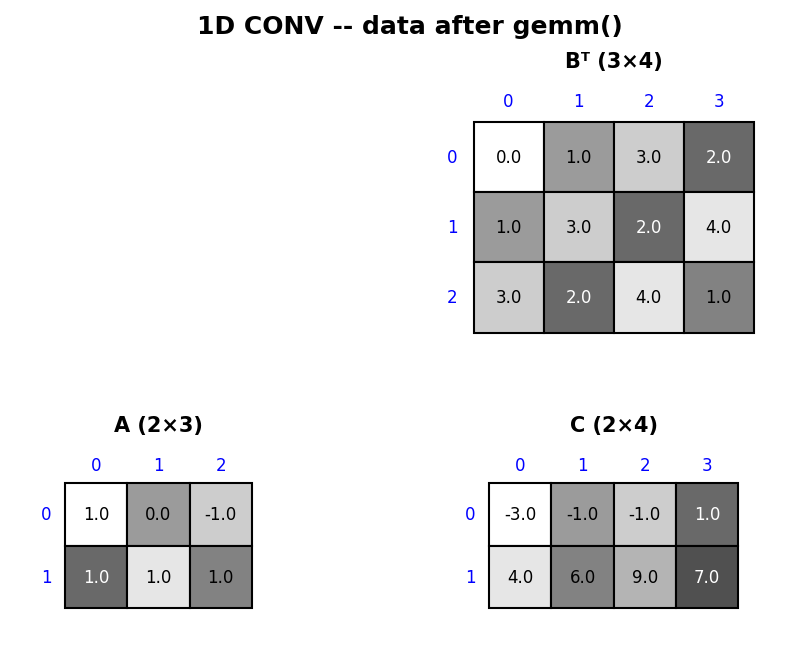

In [44]:
gemm(A, B, C)

draw_gemm(A, B, C,
          main_title='1D CONV -- data after gemm()')

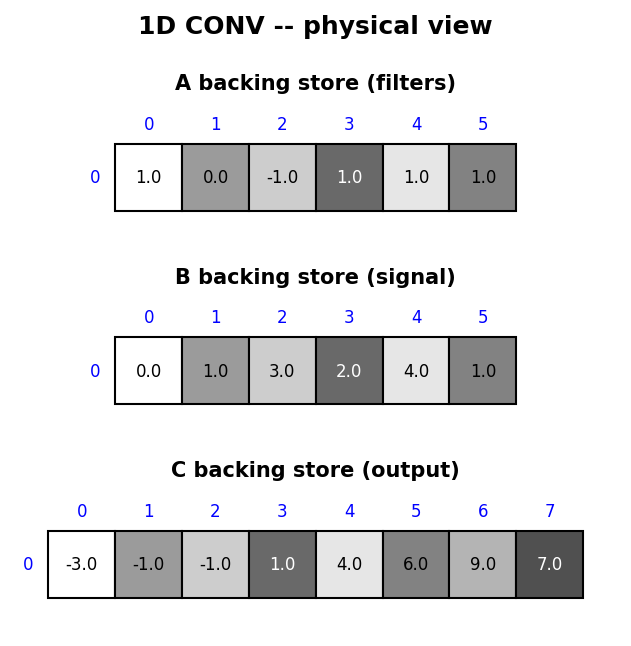

In [45]:
draw_composite(
    [A.view(Layout(len(A.data), 1)), B.view(Layout(len(B.data), 1)), C.view(Layout(len(C.data), 1))],
    titles=['A backing store (filters)', 'B backing store (signal)', 'C backing store (output)'],
    arrangement='vertical',
    main_title='1D CONV -- physical view')

### 2D Convolution

A 2D convolution (NCHW format) maps to GEMM with:
- A (filter): `(K, (C, R, S))` — K output channels, C×R×S filter volume
- B (input):  `((N, P, Q), (C, R, S))` — output positions × filter taps
- C (output): `(K, (N, P, Q))` — K channels × spatial positions

The B layout encodes the `im2col` transformation: for each output
position `(n, p, q)`, the filter tap `(c, r, s)` reads `input[n, c, p+r, q+s]`.

The `im2col` function generalizes naturally to N-D.  Compare with the
1D version above — the structure is identical, just more spatial loops:

```python
def im2col_2d(input, H, W, R, S):
    """Explicitly build the im2col matrix for 2D convolution."""
    P, Q = H - R + 1, W - S + 1
    col = []
    for p in range(P):             # each output row
        for q in range(Q):         # each output column
            for r in range(R):     # each filter row
                for s in range(S): # each filter column
                    col.append(input[(p + r) * W + (q + s)])
    return col   # flat P*Q*R*S buffer, row-major
```

For a 4×4 input with a 2×2 filter (`P=Q=3`, `R=S=2`):

```
im2col = [[inp[0], inp[1], inp[4], inp[5]],   ← window at (0,0)
          [inp[1], inp[2], inp[5], inp[6]],   ← window at (0,1)
          ...                                  ← 9 rows total
          [inp[9], inp[10], inp[13], inp[14]]] ← window at (2,2)
```

Here we build the im2col buffer explicitly for clarity, but the
point is that the same `gemm()` function handles convolution
with no code changes.

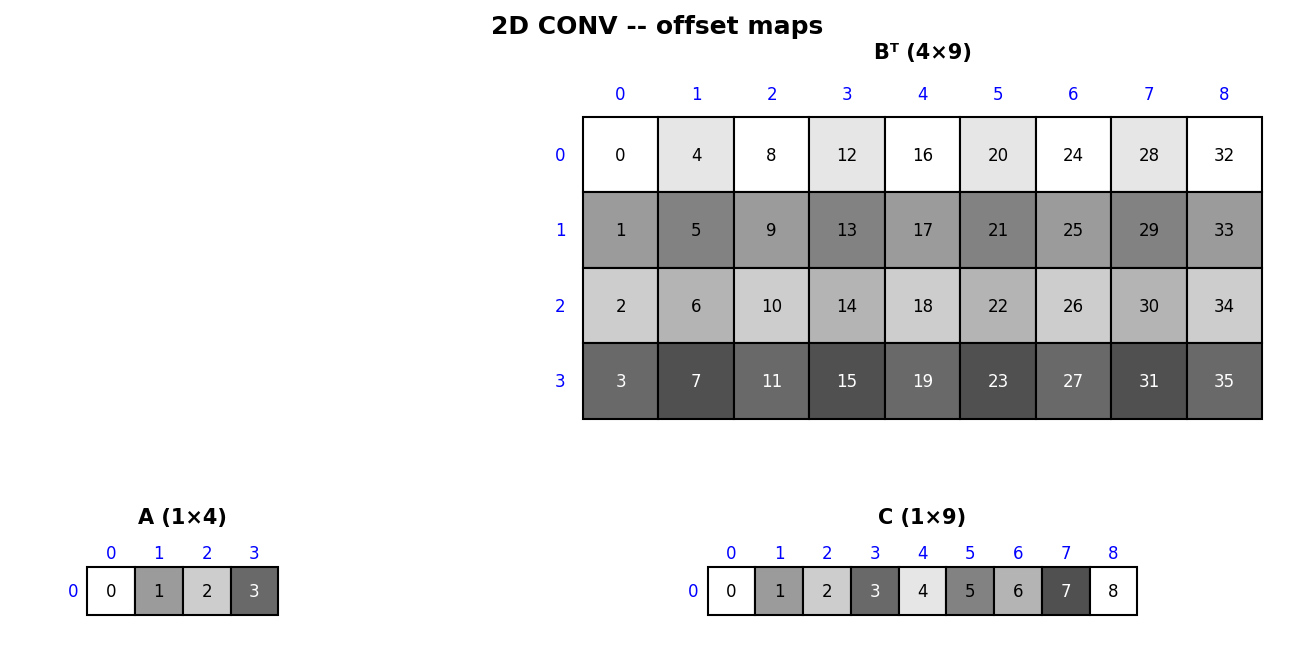

In [46]:
# 2D Conv: 1 image, 1 input channel, 4×4 input, 2×2 filter, 1 output channel
Ni, Ci, H, Wi = 1, 1, 4, 4  # input
Ko, R, S = 1, 2, 2           # filter
P, Q = H - R + 1, Wi - S + 1  # output spatial: 3×3

# Input image (single image/channel, row-major)
inp = [float(x) for x in range(H * Wi)]

# Filter: 2×2 box filter
filt = [1., 1., 1., 1.]

# A (filter): (K, C*R*S) = (1, 4)
A = Tensor(Layout((Ko, Ci*R*S), (Ci*R*S, 1)), data=filt)

# B (im2col): shape (P*Q, C*R*S)
im2col = []
for p in range(P):
    for q in range(Q):
        for r in range(R):
            for s in range(S):
                im2col.append(inp[(p+r)*Wi + (q+s)])

B = Tensor(Layout((P*Q, Ci*R*S), (Ci*R*S, 1)), data=im2col)
Cout = Tensor(Layout((Ko, P*Q), (P*Q, 1)), data=[0.] * (Ko * P * Q))

draw_gemm(A.layout, B.layout, Cout.layout,
          main_title='2D CONV -- offset maps')

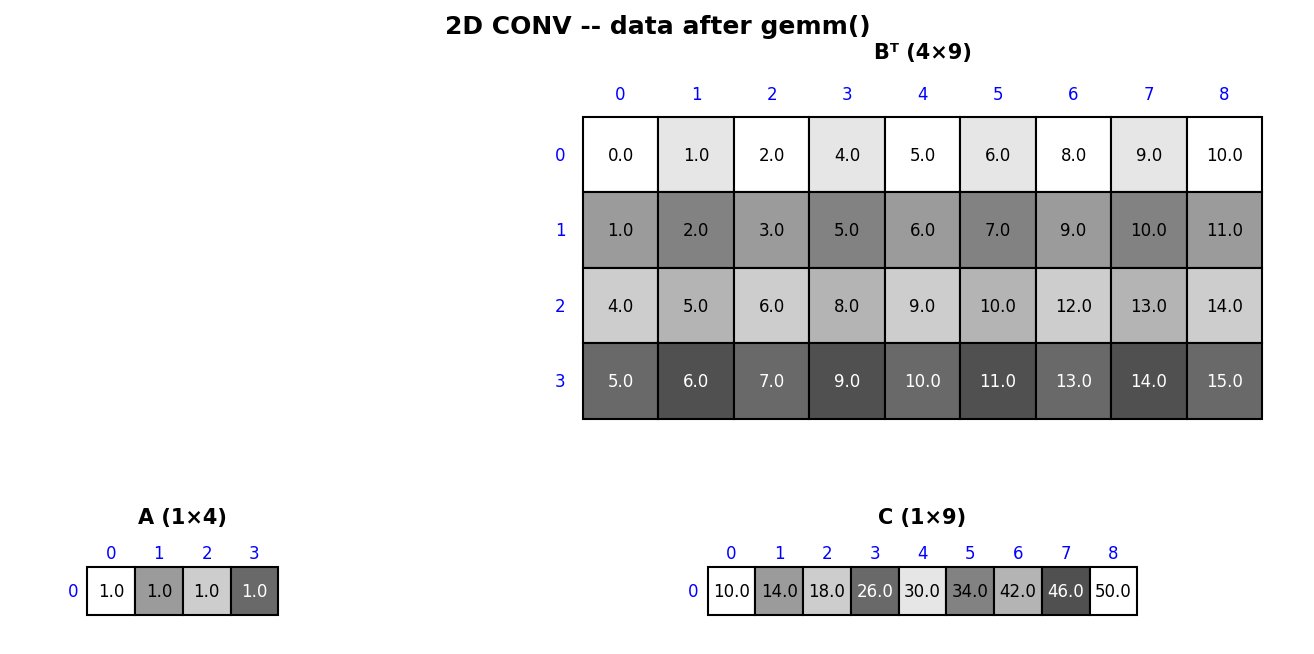

In [47]:
gemm(A, B, Cout)

draw_gemm(A, B, Cout,
          main_title='2D CONV -- data after gemm()')

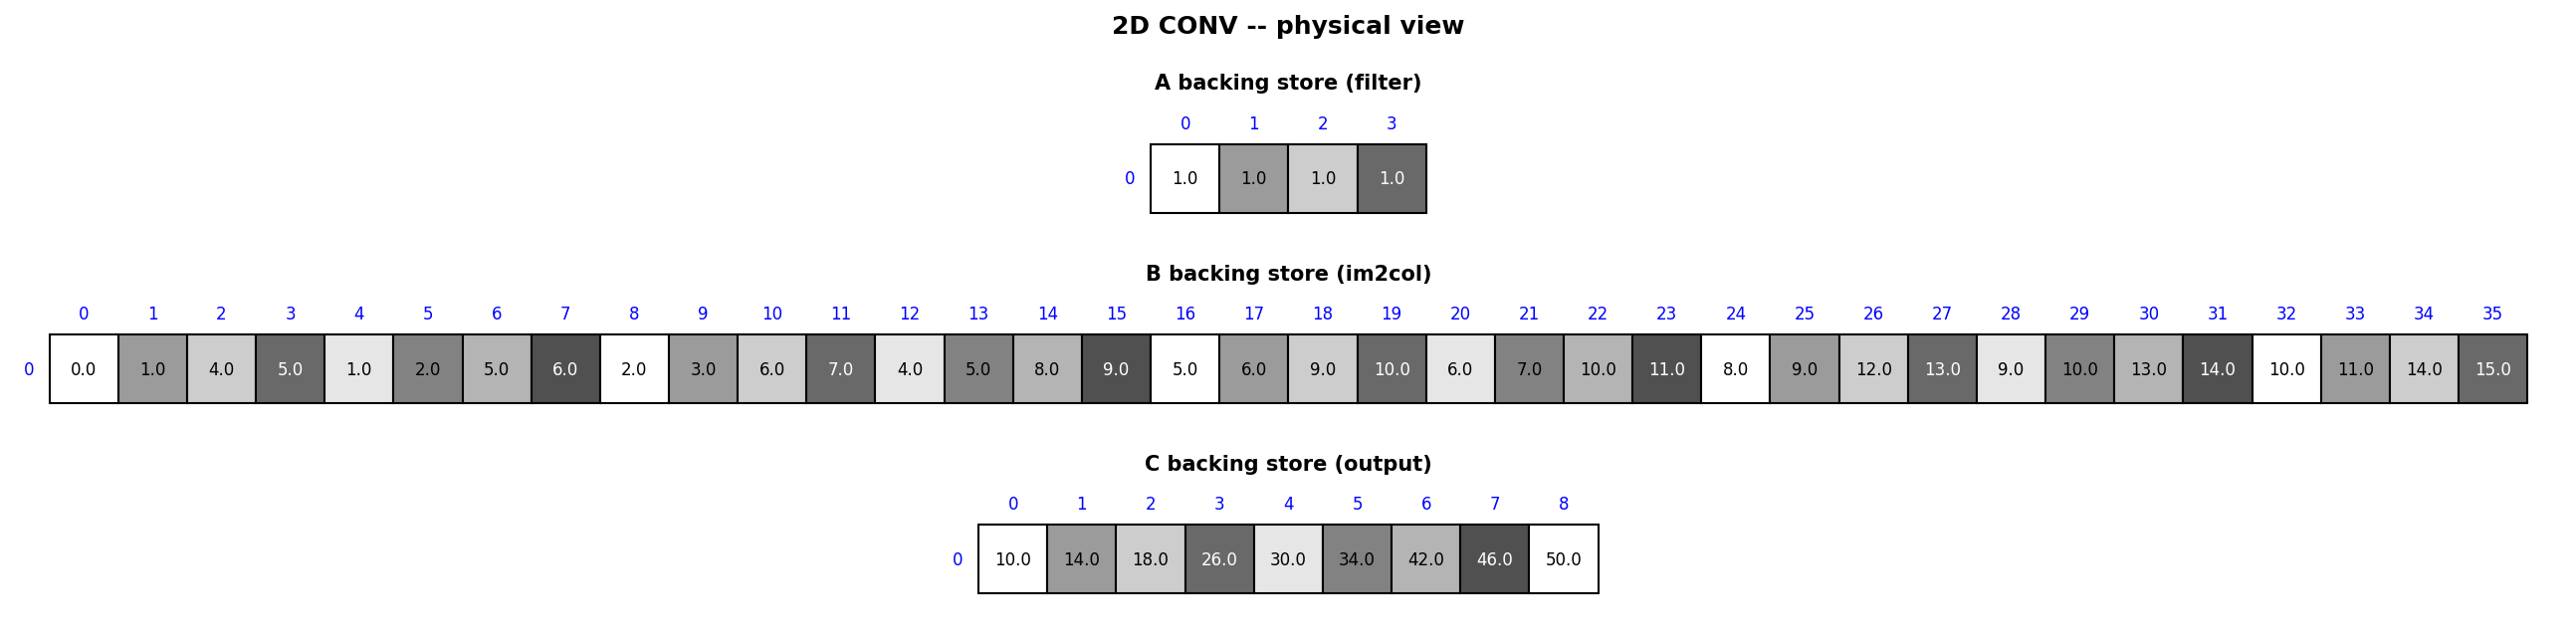

In [48]:
draw_composite(
    [A.view(Layout(len(A.data), 1)), B.view(Layout(len(B.data), 1)), Cout.view(Layout(len(Cout.data), 1))],
    titles=['A backing store (filter)', 'B backing store (im2col)', 'C backing store (output)'],
    arrangement='vertical',
    main_title='2D CONV -- physical view')

<a id="epilogue-fusion"></a>

## Epilogue Fusion

Real GPU kernels rarely run GEMM in isolation.  The output matrix C is
typically transformed in-place before being written back to global
memory — adding a bias vector, applying an activation function (ReLU,
GELU), or adding a residual tensor.  Fusing these operations into the
GEMM's "epilogue" avoids a round-trip through global memory.

From a layout algebra perspective, the epilogue composes familiar
primitives:

- **Bias add** is the broadcast pattern from COPY (§2.6.1): a 1D bias
  vector with stride 0 in one dimension is added to every row (or column)
  of C.
- **Activation** is a pointwise map — no layout needed, just `f(C[i])`
  for each element.
- Different bias layouts produce row bias vs column bias — the same
  epilogue code, different layouts, different semantics.

In [49]:
def gemm_epilogue(A, B, C, bias=None, activation=None):
    """GEMM + fused epilogue: bias add + pointwise activation.
    bias: Tensor with same size as C (broadcast via stride-0 layout)
    activation: callable applied element-wise (e.g., relu)
    """
    gemm(A, B, C)
    if bias is not None:
        for i in range(size(C)):
            C[i] += bias[i]
    if activation is not None:
        for i in range(size(C)):
            C[i] = activation(C[i])

### Bias as Broadcast Layout

A bias vector `bias: N:1` stores N values.  To add it to every row of
an `(M, N)` output, we view it as `(M, N):(0, 1)` — stride 0 in the M
dimension means every row reads the same bias values.  This is exactly
the broadcast pattern from §2.6.1:

| Epilogue op | Bias layout | Effect |
|---|---|---|
| Column bias | `(M, N):(0, 1)` | Same bias added to every row |
| Row bias | `(M, N):(1, 0)` | Same bias added to every column |

The same `gemm_epilogue()` function handles both — only the bias
layout changes.

bias layout: (3, 3) : (0, 1)
bias offsets: [0, 0, 0, 1, 1, 1, 2, 2, 2]
  -> each row reads the same 3 values from a 3-element buffer


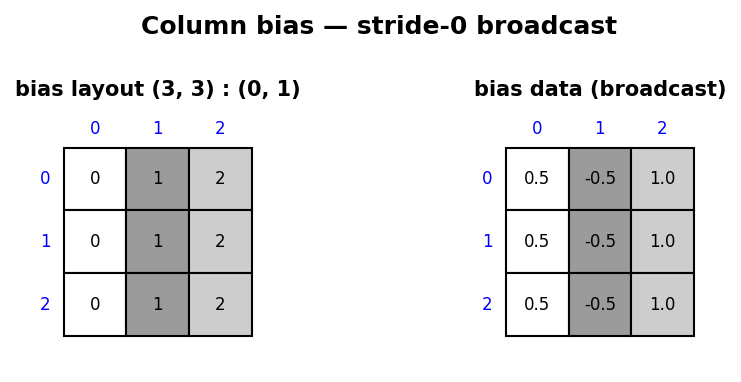

In [50]:
# Epilogue: GEMM + column bias + ReLU
M, N, K = 3, 3, 2

# A and B: col-major
A = Tensor(Layout((M, K), (1, M)), data=[1., 0., 2., -1., 1., 0.])
B = Tensor(Layout((N, K), (1, N)), data=[1., 0., 1., 0., 1., -1.])

# Column bias: shape (M,N) with stride (0,1) — broadcasts along M
bias_data = [0.5, -0.5, 1.0]
bias = Tensor(Layout((M, N), (0, 1)), data=bias_data)

# Show the bias broadcast layout
print(f"bias layout: {bias.layout}")
print(f"bias offsets: {[bias.layout(i) for i in range(size(bias))]}")
print(f"  -> each row reads the same 3 values from a 3-element buffer")

draw_composite(
    [bias.layout, bias],
    titles=[f'bias layout {bias.layout}', 'bias data (broadcast)'],
    main_title='Column bias — stride-0 broadcast')

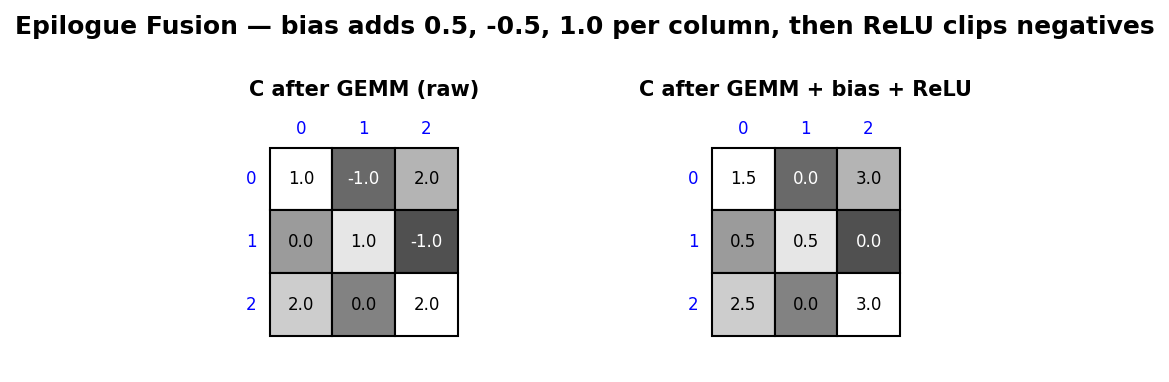

In [51]:
# Run GEMM only first, to see the raw output
C_raw = Tensor(Layout((M, N), (1, M)), data=[0.] * (M * N))
gemm(A, B, C_raw)

# Now run GEMM + bias + ReLU
relu = lambda x: max(0.0, x)
C_fused = Tensor(Layout((M, N), (1, M)), data=[0.] * (M * N))
gemm_epilogue(A, B, C_fused, bias=bias, activation=relu)

draw_composite(
    [C_raw, C_fused],
    titles=['C after GEMM (raw)', 'C after GEMM + bias + ReLU'],
    main_title='Epilogue Fusion — bias adds 0.5, -0.5, 1.0 per column, then ReLU clips negatives')

<a id="online-softmax"></a>

## Online Softmax

Softmax normalizes a vector so its elements are positive and sum to 1:

`softmax(x)[i] = exp(x[i] - max(x)) / sum_j exp(x[j] - max(x))`

This decomposes into the primitives we've already defined:

1. **REDUCE(max)** — find the maximum element (for numerical stability)
2. **Element-wise exp** — `exp(x[i] - max)`
3. **REDUCE(+)** — sum the exponentials
4. **Element-wise divide** — normalize by the sum

The standard implementation requires **two passes** over the data (one
for max, one for exp+sum).  The **online** algorithm fuses the two
reduces into a single pass by maintaining a running max and correcting
the running sum whenever the max increases:

```
running_sum *= exp(old_max - new_max)   # correct for new max
running_sum += exp(x[i] - new_max)       # incorporate new element
```

This is the key enabler for **Flash Attention**, where the attention
score matrix `S = Q × K^T` is too large to materialize.  Online softmax
lets us process K in tiles, accumulating statistics across tiles without
ever storing the full S matrix.

In [52]:
import math

def softmax(src, dst):
    """Two-pass softmax using reduce primitives.
    src: (K,)  ->  dst: (K,)
    Pass 1: m = reduce(src, max)
    Pass 2: dst[i] = exp(src[i] - m),  s = reduce(dst, +)
    Pass 3: dst[i] /= s
    """
    K = size(src)
    assert size(dst) == K
    # Pass 1: max (= reduce with op=max)
    m = float('-inf')
    for i in range(K):
        m = max(m, src[i])
    # Pass 2: exp and sum (= element-wise + reduce with op=+)
    s = 0.0
    for i in range(K):
        dst[i] = math.exp(src[i] - m)
        s += dst[i]
    # Pass 3: normalize (= element-wise)
    for i in range(K):
        dst[i] /= s

In [53]:
def online_softmax(src, dst):
    """Online softmax: fuses reduce(max) and reduce(sum) into one pass.
    When max increases, the running sum is corrected by the ratio
    exp(old_max - new_max), avoiding a separate max-finding pass.
    """
    K = size(src)
    assert size(dst) == K
    running_max = float('-inf')
    running_sum = 0.0
    # Single pass: track max and corrected sum
    for i in range(K):
        old_max = running_max
        running_max = max(running_max, src[i])
        running_sum = (running_sum * math.exp(old_max - running_max)
                       + math.exp(src[i] - running_max))
    # Final pass: compute normalized values
    for i in range(K):
        dst[i] = math.exp(src[i] - running_max) / running_sum

Two-pass:  [0.2333, 0.0858, 0.0349, 0.6343, 0.0116]
Online:    [0.2333, 0.0858, 0.0349, 0.6343, 0.0116]
Sum:       1.000000
Match confirmed — identical results from both algorithms


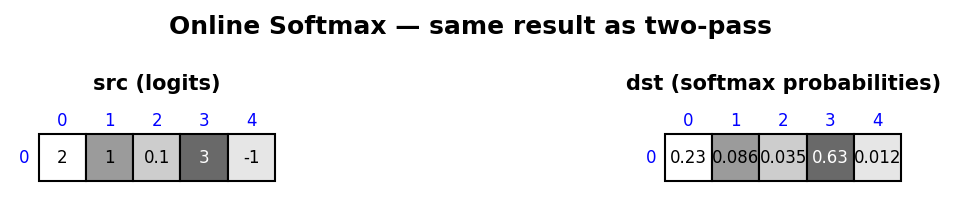

In [57]:
# Compare two-pass and online softmax on the same input
src = Tensor(Layout(5, 1), data=[2.0, 1.0, 0.1, 3.0, -1.0])
dst_two  = Tensor(Layout(5, 1), data=[0.0] * 5)
dst_online = Tensor(Layout(5, 1), data=[0.0] * 5)

softmax(src, dst_two)
online_softmax(src, dst_online)

print("Two-pass: ", [round(dst_two[i], 4) for i in range(size(dst_two))])
print("Online:   ", [round(dst_online[i], 4) for i in range(size(dst_online))])
print(f"Sum:       {sum(dst_online[i] for i in range(size(dst_online))):.6f}")

# Verify they match
assert all(abs(dst_two[i] - dst_online[i]) < 1e-10
           for i in range(size(dst_two))), "Mismatch!"
print("Match confirmed — identical results from both algorithms")

draw_composite(
    [src, dst_online],
    titles=['src (logits)', 'dst (softmax probabilities)'],
    main_title='Online Softmax — same result as two-pass',
    precision=2)

### Per-Row Softmax — Layout Determines the Reduction Axis

In attention, softmax is applied **per-row** of the score matrix
`S = Q × K^T`.  Each row represents one query's attention distribution
over all keys.  With a row-major layout, each row is a contiguous
slice — `src[m, :]` — and we apply `online_softmax` to each
independently.

  row 0: [0.5745, 0.2114, 0.0859, 0.1282]  (sum = 1.000000)
  row 1: [0.0403, 0.8098, 0.1096, 0.0403]  (sum = 1.000000)
  row 2: [0.25, 0.25, 0.25, 0.25]  (sum = 1.000000)


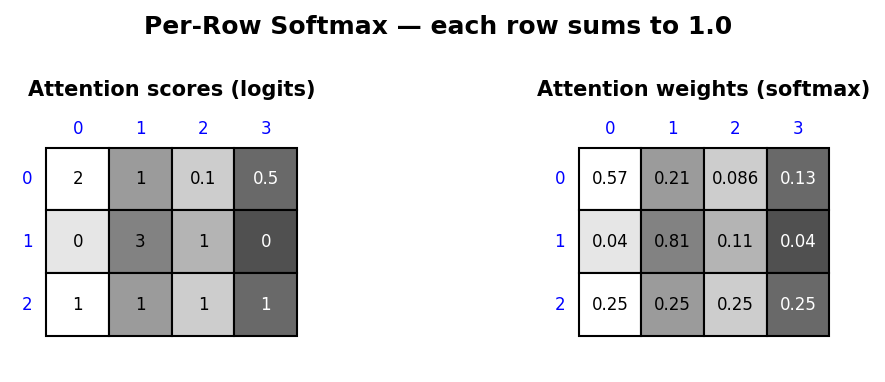

In [56]:
def row_softmax(src, dst):
    """Per-row softmax on a 2D tensor.
    src: (M, K)  ->  dst: (M, K)
    Applies online_softmax to each row independently.
    """
    M = size(mode(src, 0))
    for m in range(M):
        online_softmax(src[m, :], dst[m, :])

# 3x4 attention score matrix (row-major)
M, K = 3, 4
scores = [2.0, 1.0, 0.1, 0.5,     # query 0
          0.0, 3.0, 1.0, 0.0,     # query 1
          1.0, 1.0, 1.0, 1.0]     # query 2 (uniform)
src = Tensor(Layout((M, K), (K, 1)), data=scores)
dst = Tensor(Layout((M, K), (K, 1)), data=[0.0] * (M * K))

row_softmax(src, dst)

# Verify each row sums to 1
for m in range(M):
    row = [round(dst[m, k], 4) for k in range(K)]
    row_sum = sum(dst[m, k] for k in range(K))
    print(f"  row {m}: {row}  (sum = {row_sum:.6f})")

draw_composite(
    [src, dst],
    titles=['Attention scores (logits)', 'Attention weights (softmax)'],
    main_title='Per-Row Softmax — each row sums to 1.0',
    precision=2)

### Connection to Flash Attention

Flash Attention combines three ideas from this notebook:

1. **GEMM** (§2.6.2) computes the attention scores `S = Q × K^T`
2. **Tiling** (applications.ipynb §3.3.5) splits K into blocks via
   `logical_divide`, so the full S matrix is never materialized
3. **Online softmax** processes one K-block at a time, using
   `running_sum *= exp(old_max - new_max)` to correct statistics
   across blocks

Layout algebra handles the tiling and data movement; the online
algorithm handles the numerical fusion.  Together they reduce attention
from O(N²) memory to O(N) — without changing the mathematical result.